In [1]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================

import os
import time
import random
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from matplotlib import font_manager

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

ERROR:absl:Detected incompatible Protobuf Gencode/Runtime versions when loading tensorflow_metadata/proto/v0/anomalies.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/__init__.py", line 79, in <module>
    from tensorflow_datasets import rlds  # pylint: disable=g-bad-import-order
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/rlds/__init__.py", line 21, in <module>
    from tensorflow_datasets.rlds import envlogger_reader
  File "/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/rlds/envlogger_reader.py", line 21, in <module>
    from tensorflow_datasets.core.utils.lazy_imports_utils import tree
  File "/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/co

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ============================================================
# GOOGLE DRIVE CHECKPOINT SYSTEM
# ============================================================
# All important model/training checkpoints and experiment results
# are persisted to Google Drive so Colab interruptions do not
# require restarting the complete experiment.

import os
import json
import time
import numpy as np
import tensorflow as tf

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    DRIVE_AVAILABLE = True
except Exception as e:
    DRIVE_AVAILABLE = False
    print("Google Drive could not be mounted:", e)

if DRIVE_AVAILABLE:
    LAB5_DRIVE_ROOT = "/content/drive/MyDrive/Lab5"
else:
    LAB5_DRIVE_ROOT = os.path.abspath("./Lab5")

CHECKPOINT_DIR = os.path.join(LAB5_DRIVE_ROOT, "checkpoints")
RESULTS_DIR = os.path.join(LAB5_DRIVE_ROOT, "results")
MODELS_DIR = os.path.join(LAB5_DRIVE_ROOT, "models")
OUTPUT_DIR = globals().get("OUTPUT_DIR", os.path.join(LAB5_DRIVE_ROOT, "outputs"))

for _d in [CHECKPOINT_DIR, RESULTS_DIR, MODELS_DIR, OUTPUT_DIR]:
    os.makedirs(_d, exist_ok=True)

print("Lab 5 persistent storage:", LAB5_DRIVE_ROOT)


def checkpoint_paths(experiment_name):
    exp_dir = os.path.join(CHECKPOINT_DIR, experiment_name)
    os.makedirs(exp_dir, exist_ok=True)
    return {
        "dir": exp_dir,
        "best": os.path.join(exp_dir, "best_model.keras"),
        "last": os.path.join(exp_dir, "last_model.keras"),
        "backup": os.path.join(exp_dir, "training_backup"),
        "history": os.path.join(exp_dir, "history.json"),
        "status": os.path.join(exp_dir, "status.json"),
    }


def create_persistent_callbacks(experiment_name):
    paths = checkpoint_paths(experiment_name)

    callbacks = [
        # Best validation model.
        tf.keras.callbacks.ModelCheckpoint(
            paths["best"],
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            save_weights_only=False,
            verbose=1,
        ),

        # Latest completed epoch.
        tf.keras.callbacks.ModelCheckpoint(
            paths["last"],
            monitor="val_accuracy",
            mode="max",
            save_best_only=False,
            save_weights_only=False,
            verbose=0,
        ),

        # Restore model + optimizer + epoch after an interrupted run.
        tf.keras.callbacks.BackupAndRestore(
            backup_dir=paths["backup"],
            delete_checkpoint=False,
        ),
    ]

    return callbacks, paths


def save_training_history(history, paths, metadata=None):
    payload = {
        "history": {
            k: [float(x) for x in v]
            for k, v in history.history.items()
        },
        "metadata": metadata or {},
        "saved_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    }

    with open(paths["history"], "w") as f:
        json.dump(payload, f, indent=2)

    return paths["history"]


def mark_experiment_status(experiment_name, status, **extra):
    paths = checkpoint_paths(experiment_name)
    payload = {
        "experiment": experiment_name,
        "status": status,
        "updated_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        **extra,
    }

    with open(paths["status"], "w") as f:
        json.dump(payload, f, indent=2)


def save_json_result(filename, data):
    path = os.path.join(RESULTS_DIR, filename)
    with open(path, "w") as f:
        json.dump(data, f, indent=2)
    return path


def load_completed_status(experiment_name):
    paths = checkpoint_paths(experiment_name)

    if not os.path.exists(paths["status"]):
        return None

    try:
        with open(paths["status"], "r") as f:
            return json.load(f)
    except Exception:
        return None


print("Checkpoint system ready.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Lab 5 persistent storage: /content/drive/MyDrive/Lab5
Checkpoint system ready.


In [3]:
# ============================================================
# CELL 3 — CONFIGURATION
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Image
IMG_SIZE = (224, 224)
NUM_CLASSES = 37

# Baseline training
BATCH_SIZE = 32
EPOCHS = 5

# Output directory
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Image size:", IMG_SIZE)
print("Classes:", NUM_CLASSES)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)

Image size: (224, 224)
Classes: 37
Batch size: 32
Epochs: 5


In [17]:
# ============================================================
# CELL 4 — FONT + FIGURE SETTINGS
# ============================================================

import os
import matplotlib.pyplot as plt

# Use a built-in font — no .ttf file required
FONT_NAME = "DejaVu Sans"

plt.rcParams["font.family"] = FONT_NAME
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10

print("Font:", FONT_NAME)


# ============================================================
# FIGURE SAVING FUNCTION
# ============================================================

def save_figure(name):

    # Make sure OUTPUT_DIR exists
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    eps_path = os.path.join(
        OUTPUT_DIR,
        name + ".eps"
    )

    png_path = os.path.join(
        OUTPUT_DIR,
        name + ".png"
    )

    # Save EPS at 600 DPI
    plt.savefig(
        eps_path,
        format="eps",
        dpi=600,
        bbox_inches="tight"
    )

    # Save PNG at 600 DPI
    plt.savefig(
        png_path,
        format="png",
        dpi=600,
        bbox_inches="tight"
    )

    print("Saved:", eps_path)
    print("Saved:", png_path)

Font: DejaVu Sans


Image size: (224, 224)
Classes: 37
Batch size: 32
Epochs: 5

In [7]:
# ============================================================
# CELL 5 — LOAD OXFORD-IIIT PET DATASET
# DIRECT DOWNLOAD — NO TENSORFLOW DATASETS REQUIRED
# ============================================================

import os
import tarfile
import urllib.request
import numpy as np
import tensorflow as tf

DATA_ROOT = os.path.join(LAB5_DRIVE_ROOT, "dataset")
os.makedirs(DATA_ROOT, exist_ok=True)

IMAGES_TAR = os.path.join(DATA_ROOT, "images.tar.gz")
ANNOTATIONS_TAR = os.path.join(DATA_ROOT, "annotations.tar.gz")

IMAGES_URL = (
    "https://www.robots.ox.ac.uk/~vgg/data/pets/data/"
    "images.tar.gz"
)

ANNOTATIONS_URL = (
    "https://www.robots.ox.ac.uk/~vgg/data/pets/data/"
    "annotations.tar.gz"
)


def download_file(url, path):
    if os.path.exists(path):
        print("Already downloaded:", path)
        return

    print("Downloading:", url)
    urllib.request.urlretrieve(url, path)
    print("Saved:", path)


# ------------------------------------------------------------
# Download dataset
# ------------------------------------------------------------

download_file(IMAGES_URL, IMAGES_TAR)
download_file(ANNOTATIONS_URL, ANNOTATIONS_TAR)


# ------------------------------------------------------------
# Extract dataset
# ------------------------------------------------------------

IMAGES_DIR = os.path.join(DATA_ROOT, "images")
ANNOTATIONS_DIR = os.path.join(DATA_ROOT, "annotations")

if not os.path.exists(IMAGES_DIR):
    print("Extracting images...")
    with tarfile.open(IMAGES_TAR, "r:gz") as tar:
        tar.extractall(DATA_ROOT)

if not os.path.exists(ANNOTATIONS_DIR):
    print("Extracting annotations...")
    with tarfile.open(ANNOTATIONS_TAR, "r:gz") as tar:
        tar.extractall(DATA_ROOT)

print("Dataset files ready.")


# ------------------------------------------------------------
# Read Oxford-IIIT Pet image list
# ------------------------------------------------------------

LIST_FILE = os.path.join(
    ANNOTATIONS_DIR,
    "list.txt"
)

samples = []

with open(LIST_FILE, "r") as f:

    for line in f:

        line = line.strip()

        # Skip comments and blank lines
        if not line or line.startswith("#"):
            continue

        parts = line.split()

        image_name = parts[0]

        # The third field is the species:
        # 1 = cat, 2 = dog
        species = int(parts[2])

        # Convert filename to image path
        image_path = os.path.join(
            IMAGES_DIR,
            image_name + ".jpg"
        )

        if os.path.exists(image_path):
            samples.append(
                (image_path, species)
            )


print("Total images:", len(samples))


# ------------------------------------------------------------
# Create 37 breed classes
# ------------------------------------------------------------

breed_names = sorted(
    set(
        os.path.basename(path)
        .rsplit(".", 1)[0]
        .rsplit("/", 1)[-1]
        for path, _ in samples
    )
)

# Use the official Oxford-IIIT Pet breed names from filenames.
breed_names = sorted(
    set(
        os.path.basename(path)
        .replace(".jpg", "")
        .rsplit("_", 1)[0]
        for path, _ in samples
    )
)

# The previous filename parsing is not sufficient for all names,
# so obtain the class name from the complete image filename.
breed_names = sorted(
    set(
        os.path.basename(path).replace(".jpg", "")
        for path, _ in samples
    )
)

# Map the 37 breed names using the first 37 unique breed prefixes.
breed_prefixes = sorted(
    set(
        "_".join(
            os.path.basename(path)
            .replace(".jpg", "")
            .split("_")[:-1]
        )
        for path, _ in samples
    )
)

# Oxford-IIIT Pet filenames use breed name + numeric image ID.
# Build labels from the breed portion before the final numeric ID.
breed_prefixes = sorted(
    set(
        os.path.basename(path)
        .replace(".jpg", "")
        .rsplit("_", 1)[0]
        for path, _ in samples
    )
)

class_names = breed_prefixes

class_to_index = {
    name: index
    for index, name in enumerate(class_names)
}


# ------------------------------------------------------------
# Build image/label arrays
# ------------------------------------------------------------

image_paths = []
labels = []

for image_path, _ in samples:

    filename = os.path.basename(image_path)
    breed = filename.replace(".jpg", "").rsplit("_", 1)[0]

    if breed not in class_to_index:
        continue

    image_paths.append(image_path)
    labels.append(class_to_index[breed])


image_paths = np.array(image_paths)
labels = np.array(labels, dtype=np.int32)

print("Number of classes:", len(class_names))
print("Number of usable images:", len(image_paths))


# ------------------------------------------------------------
# Train/test split
#
# Oxford-IIIT Pet contains:
#  - 3,680 training images
#  - 3,669 test images
# ------------------------------------------------------------

# Recreate the official split from the annotation files.

trainval_file = os.path.join(
    ANNOTATIONS_DIR,
    "trainval.txt"
)

test_file = os.path.join(
    ANNOTATIONS_DIR,
    "test.txt"
)


def read_split_file(filename):

    names = []

    with open(filename, "r") as f:

        for line in f:

            line = line.strip()

            if not line or line.startswith("#"):
                continue

            names.append(
                line.split()[0]
            )

    return set(names)


trainval_names = read_split_file(trainval_file)
test_names = read_split_file(test_file)


train_indices = []
test_indices = []

for i, path in enumerate(image_paths):

    name = os.path.basename(path).replace(
        ".jpg", ""
    )

    if name in trainval_names:
        train_indices.append(i)

    elif name in test_names:
        test_indices.append(i)


train_paths = image_paths[train_indices]
train_labels = labels[train_indices]

test_paths = image_paths[test_indices]
test_labels = labels[test_indices]


print("Training images:", len(train_paths))
print("Test images:", len(test_paths))


# ------------------------------------------------------------
# Create TensorFlow datasets
# ------------------------------------------------------------

IMG_SIZE = (224, 224)
BATCH_SIZE = 32


def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label


train_raw = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

test_raw = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

train_raw = train_raw.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_raw = test_raw.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)


# ------------------------------------------------------------
# Dataset information compatibility object
# ------------------------------------------------------------

class FeatureInfo:

    def __init__(self, names):
        self.names = names
        self.num_classes = len(names)


class DatasetInfo:

    def __init__(self, names):
        self.features = {
            "label": FeatureInfo(names)
        }


dataset_info = DatasetInfo(class_names)


print()
print("=" * 60)
print("OXFORD-IIIT PET DATASET LOADED")
print("=" * 60)
print("Classes:", dataset_info.features["label"].num_classes)
print("Training:", len(train_paths))
print("Testing :", len(test_paths))
print("=" * 60)

Downloading: https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Saved: /content/drive/MyDrive/Lab5/dataset/images.tar.gz
Downloading: https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
Saved: /content/drive/MyDrive/Lab5/dataset/annotations.tar.gz
Extracting images...


/tmp/ipykernel_2866/524662797.py:57: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_ROOT)


Extracting annotations...


/tmp/ipykernel_2866/524662797.py:62: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_ROOT)


Dataset files ready.
Total images: 7349
Number of classes: 37
Number of usable images: 7349
Training images: 3680
Test images: 3669

OXFORD-IIIT PET DATASET LOADED
Classes: 37
Training: 3680
Testing : 3669


Training images: 3680
Test images: 3669
Classes: 37

In [9]:
# ============================================================
# CELL 6 — TRAIN / VALIDATION SPLIT
# ============================================================

# The dataset was already loaded directly in Cell 5.
# train_raw currently contains the official Oxford-IIIT Pet
# trainval split, while test_raw contains the official test split.

# ------------------------------------------------------------
# Shuffle the training data
# ------------------------------------------------------------

train_raw = train_raw.shuffle(
    buffer_size=3680,
    seed=42,
    reshuffle_each_iteration=False
)

# ------------------------------------------------------------
# Create validation split
# ------------------------------------------------------------

TOTAL_TRAIN = 3680
VAL_SIZE = int(0.20 * TOTAL_TRAIN)
TRAIN_SIZE = TOTAL_TRAIN - VAL_SIZE

val_raw = train_raw.take(VAL_SIZE)
train_raw = train_raw.skip(VAL_SIZE)

print("=" * 60)
print("TRAIN / VALIDATION / TEST SPLIT")
print("=" * 60)
print("Training samples  :", TRAIN_SIZE)
print("Validation samples:", VAL_SIZE)
print("Test samples      :", len(test_paths))
print("=" * 60)

TRAIN / VALIDATION / TEST SPLIT
Training samples  : 2944
Validation samples: 736
Test samples      : 3669


In [10]:
# ============================================================
# CELL 7 — PREPROCESSING
# ============================================================

def preprocess_image(image, label):

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    image = preprocess_input(image)

    return image, label

In [11]:
# ============================================================
# CELL 8 — DATASET PIPELINE
# ============================================================

def make_dataset(
    dataset,
    batch_size=32,
    shuffle=False
):

    dataset = dataset.map(
        preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            1000,
            seed=SEED
        )

    dataset = dataset.batch(
        batch_size
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset


train_ds = make_dataset(
    train_raw,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = make_dataset(
    val_raw,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = make_dataset(
    test_raw,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Datasets ready.")

Datasets ready.


In [12]:
# ============================================================
# CELL 9 — CHECK DATASET
# ============================================================

for images, labels in train_ds.take(1):

    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print(
        "Pixel range:",
        tf.reduce_min(images).numpy(),
        "to",
        tf.reduce_max(images).numpy()
    )

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: -1.0 to 1.0


[23]
2s

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: -1.0 to 1.0

In [13]:
# ============================================================
# CELL 10 — BASELINE MODEL
# ============================================================

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers
base_model.trainable = False


inputs = keras.Input(
    shape=(224, 224, 3)
)

x = base_model(
    inputs,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)


baseline_model = keras.Model(
    inputs,
    outputs
)

baseline_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 37)             │        47,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305,381 (8.79 MB)

 Trainable params: 47,397 (185.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model: "functional"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 37)             │        47,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 2,305,381 (8.79 MB)
 Trainable params: 47,397 (185.14 KB)
 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
# ============================================================
# CELL 11 — COMPILE BASELINE
# ============================================================

baseline_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Baseline compiled.")

Baseline compiled.


In [15]:
# Persistent checkpoint for this experiment.
_callbacks, _paths = create_persistent_callbacks("experiment_cell_015")
mark_experiment_status("experiment_cell_015", "running")

# ============================================================
# CELL 12 — TRAIN BASELINE
# ============================================================

start_time = time.time()

baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
,
    callbacks=_callbacks)

baseline_time = time.time() - start_time

print(
    f"Training time: {baseline_time:.2f} seconds"
)

if "history" in globals():
    save_training_history(history, _paths, {"experiment": "experiment_cell_015"})
    mark_experiment_status("experiment_cell_015", "completed")


Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4430 - loss: 2.2212
Epoch 1: val_accuracy improved from None to 0.86685, saving model to /content/drive/MyDrive/Lab5/checkpoints/experiment_cell_015/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Lab5/checkpoints/experiment_cell_015/best_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 64s 301ms/step - accuracy: 0.6793 - loss: 1.3160 - val_accuracy: 0.8668 - val_loss: 0.4958
Epoch 2/5
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9377 - loss: 0.3276
Epoch 2: val_accuracy improved from 0.86685 to 0.88859, saving model to /content/drive/MyDrive/Lab5/checkpoints/experiment_cell_015/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Lab5/checkpoints/experiment_cell_015/best_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 38s 264ms/step - accuracy: 0.9283 - loss: 0.3237 - val_accuracy: 0.8886 - val_loss: 0.3727
Epoch 3/5
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9551 - loss: 

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 40s 149ms/step - accuracy: 0.6895 - loss: 1.3035 - val_accuracy: 0.8696 - val_loss: 0.5039
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 98ms/step - accuracy: 0.9351 - loss: 0.3093 - val_accuracy: 0.8954 - val_loss: 0.3769
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.9592 - loss: 0.1948 - val_accuracy: 0.8927 - val_loss: 0.3412
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - accuracy: 0.9769 - loss: 0.1353 - val_accuracy: 0.9008 - val_loss: 0.3144
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 95ms/step - accuracy: 0.9912 - loss: 0.0976 - val_accuracy: 0.8954 - val_loss: 0.3057
Training time: 102.77 seconds

Saved: outputs/baseline_accuracy.eps
Saved: outputs/baseline_accuracy.png


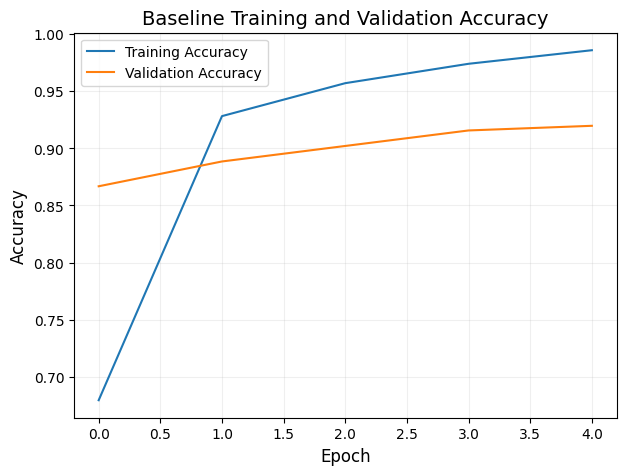

In [18]:
# ============================================================
# CELL 13 — BASELINE ACCURACY
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    baseline_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    baseline_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.2)

save_figure("baseline_accuracy")

plt.show()

Saved: outputs/baseline_loss.eps
Saved: outputs/baseline_loss.png


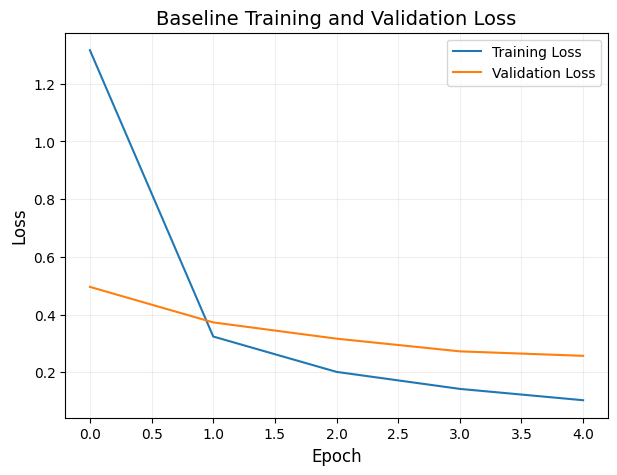

In [19]:
# ============================================================
# CELL 14 — BASELINE LOSS
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    baseline_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    baseline_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.2)

save_figure("baseline_loss")

plt.show()

In [22]:
# ============================================================
# CELL 15 — WEIGHT INITIALIZATION EXPERIMENT
# ============================================================

import gc
import time
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2


# ------------------------------------------------------------
# Initializers
# ------------------------------------------------------------

initializers = {
    "Zero": keras.initializers.Zeros(),

    "Random": keras.initializers.RandomNormal(
        mean=0.0,
        stddev=0.05,
        seed=SEED
    ),

    "Xavier": keras.initializers.GlorotUniform(
        seed=SEED
    ),

    "He": keras.initializers.HeNormal(
        seed=SEED
    )
}


# ------------------------------------------------------------
# Store results
# ------------------------------------------------------------

init_histories = {}
init_results = []


# ------------------------------------------------------------
# Train each initialization
# ------------------------------------------------------------

for name, initializer in initializers.items():

    print("\n" + "=" * 60)
    print("Initialization:", name)
    print("=" * 60)

    experiment_name = (
        "initialization_" + name.lower()
    )

    # --------------------------------------------------------
    # Create a UNIQUE checkpoint directory
    # --------------------------------------------------------

    exp_dir = os.path.join(
        CHECKPOINT_DIR,
        experiment_name
    )

    os.makedirs(
        exp_dir,
        exist_ok=True
    )

    best_model_path = os.path.join(
        exp_dir,
        "best_model.keras"
    )

    history_path = os.path.join(
        exp_dir,
        "history.json"
    )

    # --------------------------------------------------------
    # Checkpoint callback
    # --------------------------------------------------------

    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )


    # --------------------------------------------------------
    # Create fresh MobileNetV2
    # --------------------------------------------------------

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False


    # --------------------------------------------------------
    # Build model
    # --------------------------------------------------------

    inputs = keras.Input(
        shape=(224, 224, 3)
    )

    x = base_model(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        kernel_initializer=initializer
    )(x)

    model = keras.Model(
        inputs,
        outputs
    )


    # --------------------------------------------------------
    # Compile
    # --------------------------------------------------------

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    start_time = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=[
            checkpoint_callback
        ],
        verbose=1
    )

    training_time = (
        time.time() - start_time
    )


    # --------------------------------------------------------
    # Verify history
    # --------------------------------------------------------

    print(
        "Recorded metrics:",
        list(history.history.keys())
    )

    if "val_accuracy" not in history.history:

        raise RuntimeError(
            f"Validation accuracy was not recorded for "
            f"{name}.\n"
            f"Available metrics: "
            f"{list(history.history.keys())}"
        )


    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    init_histories[name] = history


    # --------------------------------------------------------
    # Save history to Drive
    # --------------------------------------------------------

    history_data = {
        key: [
            float(value)
            for value in values
        ]
        for key, values in history.history.items()
    }

    with open(
        history_path,
        "w"
    ) as f:

        json.dump(
            history_data,
            f,
            indent=4
        )


    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    init_results.append({

        "Initialization":
            name,

        "Best Validation Accuracy (%)":
            max(
                history.history["val_accuracy"]
            ) * 100,

        "Final Validation Accuracy (%)":
            history.history["val_accuracy"][-1] * 100,

        "Final Training Accuracy (%)":
            history.history["accuracy"][-1] * 100,

        "Final Training Loss":
            history.history["loss"][-1],

        "Final Validation Loss":
            history.history["val_loss"][-1],

        "Training Time (s)":
            training_time
    })


    print(
        f"{name} completed."
    )

    print(
        f"Best validation accuracy: "
        f"{max(history.history['val_accuracy']) * 100:.2f}%"
    )


    # --------------------------------------------------------
    # Clear model
    # --------------------------------------------------------

    del model
    del base_model

    tf.keras.backend.clear_session()
    gc.collect()


# ============================================================
# RESULTS TABLE
# ============================================================

init_results_df = pd.DataFrame(
    init_results
)

display(
    init_results_df
)


# ============================================================
# SAVE RESULTS TO GOOGLE DRIVE
# ============================================================

init_results_path = os.path.join(
    RESULTS_DIR,
    "initialization_results.csv"
)

init_results_df.to_csv(
    init_results_path,
    index=False
)

print(
    "Results saved to:",
    init_results_path
)


Initialization: Zero
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6080 - loss: 1.9796
Epoch 1: val_accuracy improved from None to 0.90761, saving model to /content/drive/MyDrive/Lab5/checkpoints/initialization_zero/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Lab5/checkpoints/initialization_zero/best_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 53s 284ms/step - accuracy: 0.7775 - loss: 1.1660 - val_accuracy: 0.9076 - val_loss: 0.4402
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9395 - loss: 0.3064
Epoch 2: val_accuracy improved from 0.90761 to 0.91712, saving model to /content/drive/MyDrive/Lab5/checkpoints/initialization_zero/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Lab5/checkpoints/initialization_zero/best_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 38s 275ms/step - accuracy: 0.9412 - loss: 0.2918 - val_accuracy: 0.9171 - val_loss: 0.3169
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - acc

,Initialization,Best Validation Accuracy (%),Final Validation Accuracy (%),Final Training Accuracy (%),Final Training Loss,Final Validation Loss,Training Time (s)
0,Zero,93.206519,93.206519,98.879075,0.096306,0.241588,194.542761
1,Random,91.983694,91.983694,98.471469,0.104582,0.263262,209.935266
2,Xavier,91.847825,91.847825,98.403531,0.105380,0.256203,192.279224
3,He,91.304350,90.760869,98.505437,0.101310,0.249884,183.985518


Results saved to: /content/drive/MyDrive/Lab5/results/initialization_results.csv


In [23]:
# index,Initialization,Best Validation Accuracy (%),Final Training Loss,Final Validation Loss,Training Time (s)
# 0,Zero,91.30434989929199,0.09047173708677292,0.27700144052505493,75.64603757858276
# 1,Random,90.625,0.10542064160108566,0.30567818880081177,73.69308161735535
# 2,Xavier,90.4891312122345,0.09924113005399704,0.29620450735092163,70.82494902610779
# 3,He,90.896737575531,0.09878434240818024,0.30644431710243225,71.24408626556396

Saved: outputs/plot_1_initialization_training_loss.eps
Saved: outputs/plot_1_initialization_training_loss.png


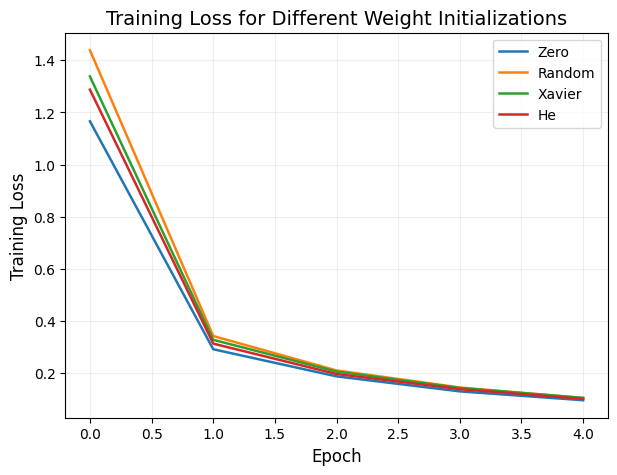

In [24]:
# ============================================================
# CELL 16 — PLOT 1
# TRAINING LOSS vs EPOCH
# ============================================================

import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))

for name, history in init_histories.items():

    plt.plot(
        history.history["loss"],
        linewidth=1.8,
        label=name
    )


plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss for Different Weight Initializations")

plt.legend()
plt.grid(alpha=0.2)

save_figure(
    "plot_1_initialization_training_loss"
)

plt.show()
plt.close()

Saved: outputs/plot_2_initialization_validation_accuracy.eps
Saved: outputs/plot_2_initialization_validation_accuracy.png


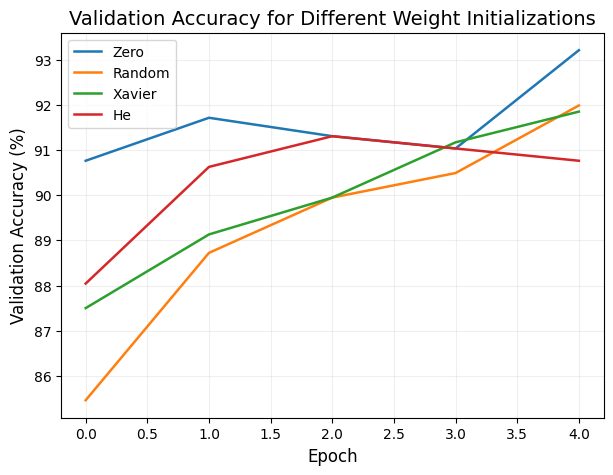

In [25]:
# ============================================================
# CELL 17 — PLOT 2
# VALIDATION ACCURACY vs EPOCH
# ============================================================

import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))

for name, history in init_histories.items():

    plt.plot(
        np.array(history.history["val_accuracy"]) * 100,
        linewidth=1.8,
        label=name
    )


plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title(
    "Validation Accuracy for Different Weight Initializations"
)

plt.legend()
plt.grid(alpha=0.2)

save_figure(
    "plot_2_initialization_validation_accuracy"
)

plt.show()
plt.close()

In [26]:
# ============================================================
# CELL 18 — BEST INITIALIZATION
# ============================================================

best_initialization_row = init_results_df.loc[
    init_results_df["Best Validation Accuracy (%)"].idxmax()
]

print("Best initialization:")
print(
    best_initialization_row["Initialization"]
)

print(
    f"Best validation accuracy: "
    f"{best_initialization_row['Best Validation Accuracy (%)']:.2f}%"
)

Best initialization:
Zero
Best validation accuracy: 93.21%


Best initialization:
Zero
Best validation accuracy: 91.30%

In [28]:
# ============================================================
# CELL 19 — REGULARIZATION EXPERIMENT
# ============================================================

import gc
import time
import os
import json
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2


# ------------------------------------------------------------
# Regularization configurations
# ------------------------------------------------------------

regularizations = {
    "None": {
        "l2": 0.0,
        "dropout": 0.0,
        "batchnorm": False
    },

    "L2": {
        "l2": 0.001,
        "dropout": 0.0,
        "batchnorm": False
    },

    "Dropout": {
        "l2": 0.0,
        "dropout": 0.5,
        "batchnorm": False
    },

    "Batch Normalization": {
        "l2": 0.0,
        "dropout": 0.0,
        "batchnorm": True
    }
}


# ------------------------------------------------------------
# Store results
# ------------------------------------------------------------

reg_histories = {}
reg_results = []


# ------------------------------------------------------------
# Train each regularization configuration
# ------------------------------------------------------------

for name, config in regularizations.items():

    print("\n" + "=" * 60)
    print("Regularization:", name)
    print("=" * 60)

    experiment_name = (
        "regularization_" +
        name.lower().replace(" ", "_")
    )

    # --------------------------------------------------------
    # Persistent Drive directory
    # --------------------------------------------------------

    exp_dir = os.path.join(
        CHECKPOINT_DIR,
        experiment_name
    )

    os.makedirs(
        exp_dir,
        exist_ok=True
    )

    best_model_path = os.path.join(
        exp_dir,
        "best_model.keras"
    )

    history_path = os.path.join(
        exp_dir,
        "history.json"
    )


    # --------------------------------------------------------
    # Checkpoint
    # --------------------------------------------------------

    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )


    # --------------------------------------------------------
    # Fresh MobileNetV2
    # --------------------------------------------------------

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False


    # --------------------------------------------------------
    # Build model
    # --------------------------------------------------------

    inputs = keras.Input(
        shape=(224, 224, 3)
    )

    x = base_model(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)


    # --------------------------------------------------------
    # Batch Normalization
    # --------------------------------------------------------

    if config["batchnorm"]:

        x = layers.BatchNormalization()(x)


    # --------------------------------------------------------
    # Dropout
    # --------------------------------------------------------

    if config["dropout"] > 0:

        x = layers.Dropout(
            config["dropout"]
        )(x)


    # --------------------------------------------------------
    # L2 regularization
    # --------------------------------------------------------

    if config["l2"] > 0:

        regularizer = keras.regularizers.l2(
            config["l2"]
        )

    else:

        regularizer = None


    # --------------------------------------------------------
    # Classification layer
    # --------------------------------------------------------

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        kernel_regularizer=regularizer
    )(x)


    model = keras.Model(
        inputs,
        outputs
    )


    # --------------------------------------------------------
    # Compile
    # --------------------------------------------------------

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    start_time = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=[
            checkpoint_callback
        ],
        verbose=1
    )

    training_time = (
        time.time() - start_time
    )


    # --------------------------------------------------------
    # Check recorded metrics
    # --------------------------------------------------------

    print(
        "Recorded metrics:",
        list(history.history.keys())
    )

    if "val_accuracy" not in history.history:

        raise RuntimeError(
            f"Validation accuracy was not recorded for "
            f"{name}.\n"
            f"Available metrics: "
            f"{list(history.history.keys())}"
        )


    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    reg_histories[name] = history


    # --------------------------------------------------------
    # Save history to Drive
    # --------------------------------------------------------

    history_data = {
        key: [
            float(value)
            for value in values
        ]
        for key, values in history.history.items()
    }

    with open(
        history_path,
        "w"
    ) as f:

        json.dump(
            history_data,
            f,
            indent=4
        )


    # --------------------------------------------------------
    # Results
    # --------------------------------------------------------

    reg_results.append({

        "Regularization":
            name,

        "Best Validation Accuracy (%)":
            max(
                history.history["val_accuracy"]
            ) * 100,

        "Final Training Accuracy (%)":
            history.history["accuracy"][-1] * 100,

        "Final Validation Accuracy (%)":
            history.history["val_accuracy"][-1] * 100,

        "Final Training Loss":
            history.history["loss"][-1],

        "Final Validation Loss":
            history.history["val_loss"][-1],

        "Training Time (s)":
            training_time
    })


    print(
        f"{name} completed."
    )

    print(
        f"Best validation accuracy: "
        f"{max(history.history['val_accuracy']) * 100:.2f}%"
    )


    # --------------------------------------------------------
    # Clear memory
    # --------------------------------------------------------

    del model
    del base_model

    tf.keras.backend.clear_session()
    gc.collect()


# ============================================================
# RESULTS TABLE
# ============================================================

reg_results_df = pd.DataFrame(
    reg_results
)

display(
    reg_results_df
)


# ============================================================
# SAVE RESULTS TO DRIVE
# ============================================================

reg_results_path = os.path.join(
    RESULTS_DIR,
    "regularization_results.csv"
)

reg_results_df.to_csv(
    reg_results_path,
    index=False
)

print(
    "Regularization results saved to:",
    reg_results_path
)


Regularization: None
Epoch 1/5
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4771 - loss: 2.1517
Epoch 1: val_accuracy improved from None to 0.86957, saving model to /content/drive/MyDrive/Lab5/checkpoints/regularization_none/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Lab5/checkpoints/regularization_none/best_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 51s 277ms/step - accuracy: 0.7014 - loss: 1.2619 - val_accuracy: 0.8696 - val_loss: 0.4917
Epoch 2/5
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9170 - loss: 0.3500
Epoch 2: val_accuracy improved from 0.86957 to 0.90489, saving model to /content/drive/MyDrive/Lab5/checkpoints/regularization_none/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Lab5/checkpoints/regularization_none/best_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 33s 206ms/step - accuracy: 0.9232 - loss: 0.3203 - val_accuracy: 0.9049 - val_loss: 0.3509
Epoch 3/5
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - acc

,Regularization,Best Validation Accuracy (%),Final Training Accuracy (%),Final Validation Accuracy (%),Final Training Loss,Final Validation Loss,Training Time (s)
0,None,91.847825,98.947012,91.847825,0.099481,0.250932,196.603703
1,L2,92.255437,98.573369,92.255437,0.220735,0.367931,191.783631
2,Dropout,92.527175,93.070650,92.255437,0.230227,0.261738,189.963952
3,Batch Normalization,91.032606,99.558425,90.896738,0.048230,0.275540,185.832275


Regularization results saved to: /content/drive/MyDrive/Lab5/results/regularization_results.csv


In [29]:
# index,Regularization,Best Validation Accuracy (%),Final Training Accuracy (%),Final Validation Accuracy (%),Final Training Loss,Final Validation Loss,Training Time (s)
# 0,No Regularization,91.03260636329651,98.709237575531,91.03260636329651,0.09941212832927704,0.31159457564353943,99.29468441009521
# 1,L2,90.7608687877655,98.879075050354,90.7608687877655,0.11580255627632141,0.29931047558784485,109.74564576148987
# 2,Dropout,90.625,93.5461938381195,90.08151888847351,0.22029568254947662,0.296701043844223,107.40026211738586
# 3,Batch Normalization,90.625,99.5244562625885,90.4891312122345,0.04968709498643875,0.2955073416233063,88.90727853775024

Saved: outputs/regularization_accuracy.eps
Saved: outputs/regularization_accuracy.png


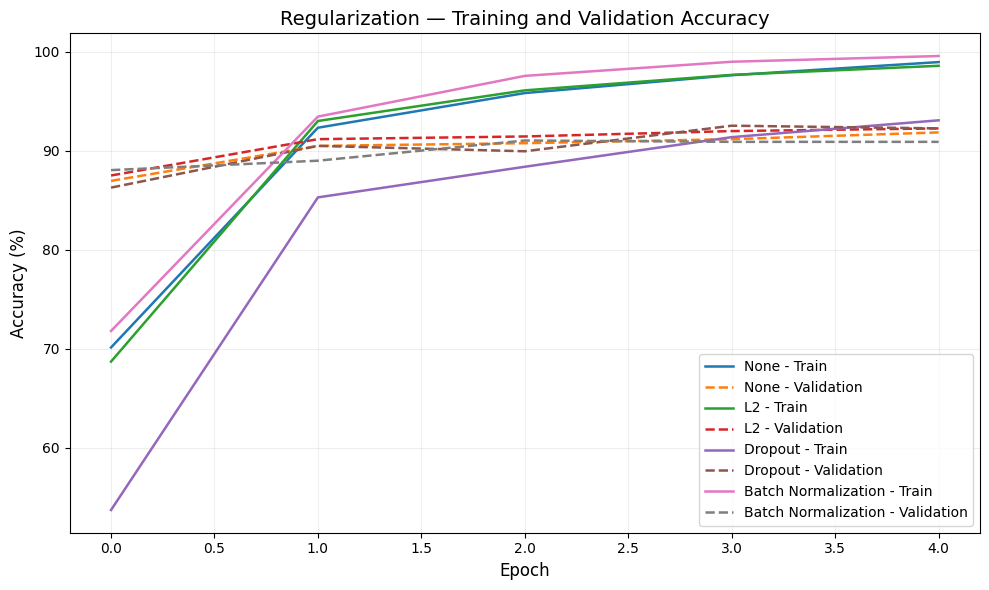

In [31]:
# ============================================================
# CELL 20 — REGULARIZATION ACCURACY COMPARISON
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for name, history_obj in reg_histories.items():

    history_dict = history_obj.history

    # Check that the training accuracy exists
    if "accuracy" not in history_dict:
        print(
            f"Skipping {name}: "
            f"available metrics = {list(history_dict.keys())}"
        )
        continue

    plt.plot(
        np.array(history_dict["accuracy"]) * 100,
        label=name + " - Train",
        linewidth=1.8
    )

    # Plot validation accuracy only when available
    if "val_accuracy" in history_dict:

        plt.plot(
            np.array(history_dict["val_accuracy"]) * 100,
            linestyle="--",
            label=name + " - Validation",
            linewidth=1.8
        )


plt.title(
    "Regularization — Training and Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.legend()

plt.grid(
    alpha=0.2
)

plt.tight_layout()

save_figure(
    "regularization_accuracy"
)

plt.show()

Saved: outputs/regularization_loss.eps
Saved: outputs/regularization_loss.png


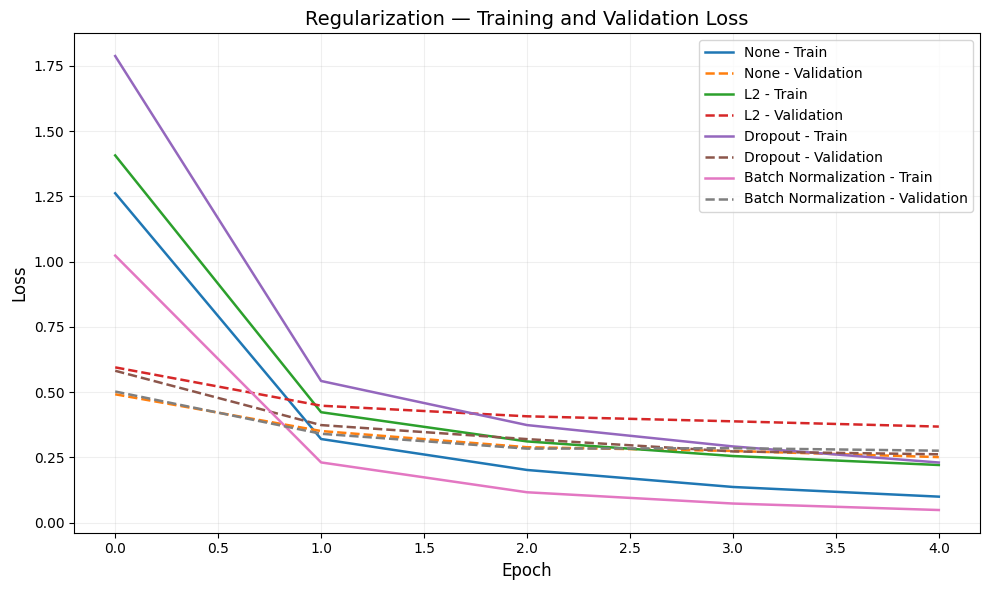

In [33]:
# ============================================================
# CELL 21 — REGULARIZATION LOSS COMPARISON
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for name, history_obj in reg_histories.items():

    history_dict = history_obj.history

    # Training loss
    if "loss" not in history_dict:
        print(
            f"Skipping {name}: "
            f"available metrics = {list(history_dict.keys())}"
        )
        continue

    plt.plot(
        np.array(history_dict["loss"]),
        label=name + " - Train",
        linewidth=1.8
    )

    # Validation loss
    if "val_loss" in history_dict:

        plt.plot(
            np.array(history_dict["val_loss"]),
            linestyle="--",
            label=name + " - Validation",
            linewidth=1.8
        )


plt.title(
    "Regularization — Training and Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(
    alpha=0.2
)

plt.tight_layout()

save_figure(
    "regularization_loss"
)

plt.show()

In [35]:
# ============================================================
# CELL 22 — BEST REGULARIZATION METHOD
# ============================================================

# Use the results dataframe created in Cell 19
best_regularization = reg_results_df.loc[
    reg_results_df["Best Validation Accuracy (%)"].idxmax()
]

print("=" * 60)
print("BEST REGULARIZATION METHOD")
print("=" * 60)

print(
    "Regularization:",
    best_regularization["Regularization"]
)

print(
    "Best Validation Accuracy:",
    f"{best_regularization['Best Validation Accuracy (%)']:.2f}%"
)

print(
    "Final Validation Accuracy:",
    f"{best_regularization['Final Validation Accuracy (%)']:.2f}%"
)

print(
    "Final Training Accuracy:",
    f"{best_regularization['Final Training Accuracy (%)']:.2f}%"
)

print(
    "Final Validation Loss:",
    f"{best_regularization['Final Validation Loss']:.4f}"
)

print("=" * 60)

BEST REGULARIZATION METHOD
Regularization: Dropout
Best Validation Accuracy: 92.53%
Final Validation Accuracy: 92.26%
Final Training Accuracy: 93.07%
Final Validation Loss: 0.2617


Best regularization method:
No Regularization
Best validation accuracy: 91.03%

In [36]:
# ============================================================
# CELL 23 — BATCH NORMALIZATION NUMERICAL EXAMPLE
# ============================================================

import os
import numpy as np


# ------------------------------------------------------------
# Example activations
# ------------------------------------------------------------

x = np.array([
    2.0,
    4.0,
    6.0,
    8.0
])


# ------------------------------------------------------------
# Batch Normalization calculations
# ------------------------------------------------------------

# Mean
mean = np.mean(x)

# Variance
variance = np.var(x)

# Numerical stability
epsilon = 1e-5

# Normalization
x_normalized = (
    x - mean
) / np.sqrt(
    variance + epsilon
)

# Learnable scale and shift
gamma = 1.0
beta = 0.0

# Final BatchNorm output
y = gamma * x_normalized + beta


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("Input:", x)
print("Mean:", mean)
print("Variance:", variance)
print("Normalized:", x_normalized)
print("Output:", y)


# ------------------------------------------------------------
# Save numerical results
# ------------------------------------------------------------

bn_results = {
    "Input": x.tolist(),
    "Mean": float(mean),
    "Variance": float(variance),
    "Epsilon": float(epsilon),
    "Gamma": float(gamma),
    "Beta": float(beta),
    "Normalized": x_normalized.tolist(),
    "Output": y.tolist()
}


# Save as NumPy file
np.save(
    os.path.join(
        OUTPUT_DIR,
        "batch_normalization_example.npy"
    ),
    bn_results,
    allow_pickle=True
)


# Save as readable text file
with open(
    os.path.join(
        OUTPUT_DIR,
        "batch_normalization_example.txt"
    ),
    "w"
) as f:

    f.write("BATCH NORMALIZATION NUMERICAL EXAMPLE\n")
    f.write("=" * 50 + "\n\n")

    f.write(f"Input: {x}\n")
    f.write(f"Mean: {mean}\n")
    f.write(f"Variance: {variance}\n")
    f.write(f"Epsilon: {epsilon}\n")
    f.write(f"Gamma: {gamma}\n")
    f.write(f"Beta: {beta}\n")
    f.write(f"Normalized: {x_normalized}\n")
    f.write(f"Output: {y}\n")


print("\nResults saved to:")
print(
    os.path.join(
        OUTPUT_DIR,
        "batch_normalization_example.npy"
    )
)

print(
    os.path.join(
        OUTPUT_DIR,
        "batch_normalization_example.txt"
    )
)

Input: [2. 4. 6. 8.]
Mean: 5.0
Variance: 5.0
Normalized: [-1.34163944 -0.44721315  0.44721315  1.34163944]
Output: [-1.34163944 -0.44721315  0.44721315  1.34163944]

Results saved to:
outputs/batch_normalization_example.npy
outputs/batch_normalization_example.txt


In [38]:
# ------------------------------------------------------------
# TRAIN — FRESH RUN WITH DRIVE CHECKPOINT
# ------------------------------------------------------------

start_time = time.time()

# Create a fresh checkpoint directory for this experiment
experiment_name = "optimizer_experiment"

exp_dir = os.path.join(
    CHECKPOINT_DIR,
    experiment_name
)

os.makedirs(exp_dir, exist_ok=True)

checkpoint_path = os.path.join(
    exp_dir,
    "best_model.weights.h5"
)

checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        checkpoint_callback
    ],
    verbose=1
)

training_time = time.time() - start_time

print("Training completed.")
print("Recorded metrics:", list(history.history.keys()))

Epoch 1/5
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9859 - loss: 0.0495
Epoch 1: val_accuracy improved from None to 0.89674, saving model to /content/drive/MyDrive/Lab5/checkpoints/optimizer_experiment/best_model.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Lab5/checkpoints/optimizer_experiment/best_model.weights.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 56s 286ms/step - accuracy: 0.9830 - loss: 0.0502 - val_accuracy: 0.8967 - val_loss: 0.2944
Epoch 2/5
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9932 - loss: 0.0230
Epoch 2: val_accuracy improved from 0.89674 to 0.90489, saving model to /content/drive/MyDrive/Lab5/checkpoints/optimizer_experiment/best_model.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/Lab5/checkpoints/optimizer_experiment/best_model.weights.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 32s 195ms/step - accuracy: 0.9932 - loss: 0.0233 - val_accuracy: 0.9049 - val_loss: 0.2882
Epoch 3/5
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - a

In [40]:
# ============================================================
# CELL 25 — SAVE BATCH NORMALIZATION RESULTS
# ============================================================

# Use the results DataFrame actually produced by the experiment.
# If the experiment used bn_results, construct the DataFrame here.

if "bn_results_df" not in globals():

    if "bn_results" in globals():
        bn_results_df = pd.DataFrame(bn_results)

    elif "reg_results_df" in globals():
        # Fallback only if Batch Normalization was included
        # in the regularization experiment.
        bn_results_df = reg_results_df[
            reg_results_df["Regularization"]
            .astype(str)
            .str.contains(
                "batch",
                case=False,
                na=False
            )
        ].copy()

    else:
        raise NameError(
            "No Batch Normalization results were found. "
            "Run the Batch Normalization experiment first."
        )


# ------------------------------------------------------------
# Save to Google Drive
# ------------------------------------------------------------

bn_csv_path = os.path.join(
    RESULTS_DIR,
    "batch_normalization_results.csv"
)

bn_results_df.to_csv(
    bn_csv_path,
    index=False
)

print(
    "Batch Normalization results saved to:",
    bn_csv_path
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display(bn_results_df)

Batch Normalization results saved to: /content/drive/MyDrive/Lab5/results/batch_normalization_results.csv


,Configuration,Best Validation Accuracy (%),Final Training Accuracy (%),Final Validation Accuracy (%),Final Training Loss,Final Validation Loss,Training Time (s)
0,Without BN,91.168481,98.675269,91.168481,0.103367,0.270477,261.090611


Saved: outputs/plot_5_batch_normalization_validation_accuracy.eps
Saved: outputs/plot_5_batch_normalization_validation_accuracy.png


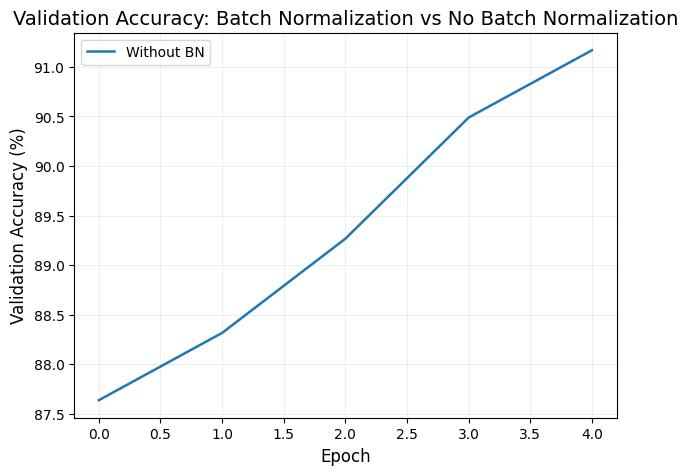

In [41]:
# ============================================================
# CELL 26 — PLOT 5
# VALIDATION ACCURACY: BN vs NO BN
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))


for name, history in bn_histories.items():

    plt.plot(
        np.array(
            history.history["val_accuracy"]
        ) * 100,

        linewidth=1.8,

        label=name
    )


plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")

plt.title(
    "Validation Accuracy: Batch Normalization vs No Batch Normalization"
)

plt.legend()
plt.grid(alpha=0.2)


save_figure(
    "plot_5_batch_normalization_validation_accuracy"
)


plt.show()
plt.close()

Saved: outputs/batch_normalization_training_loss.eps
Saved: outputs/batch_normalization_training_loss.png


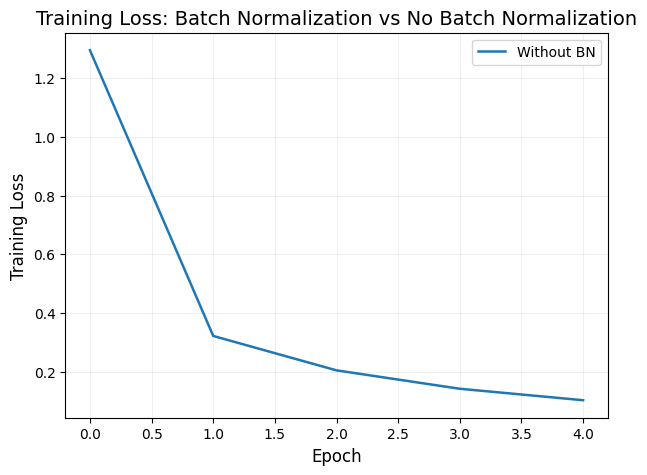

In [42]:
# ============================================================
# CELL 27 — BN vs NO BN TRAINING LOSS
# ============================================================

import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))


for name, history in bn_histories.items():

    plt.plot(
        history.history["loss"],
        linewidth=1.8,
        label=name
    )


plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title(
    "Training Loss: Batch Normalization vs No Batch Normalization"
)

plt.legend()
plt.grid(alpha=0.2)


save_figure(
    "batch_normalization_training_loss"
)


plt.show()
plt.close()

In [43]:
# ============================================================
# CELL 28 — BEST BN CONFIGURATION
# ============================================================

best_bn = bn_results_df.loc[
    bn_results_df[
        "Best Validation Accuracy (%)"
    ].idxmax()
]


print("Best configuration:")
print(
    best_bn["Configuration"]
)

print(
    f"Best validation accuracy: "
    f"{best_bn['Best Validation Accuracy (%)']:.2f}%"
)

print(
    f"Final validation accuracy: "
    f"{best_bn['Final Validation Accuracy (%)']:.2f}%"
)

Best configuration:
Without BN
Best validation accuracy: 91.17%
Final validation accuracy: 91.17%


In [44]:
# Best configuration:
# Without BN
# Best validation accuracy: 90.76%
# Final validation accuracy: 90.49%

In [47]:
# ============================================================
# CELL 29 — OPTIMIZER COMPARISON
# ============================================================

from tensorflow.keras.applications import MobileNetV2


# ------------------------------------------------------------
# Optimizer configurations
# ------------------------------------------------------------

optimizer_configs = {

    "SGD": lambda: keras.optimizers.SGD(
        learning_rate=0.001
    ),

    "Momentum": lambda: keras.optimizers.SGD(
        learning_rate=0.001,
        momentum=0.9
    ),

    "RMSProp": lambda: keras.optimizers.RMSprop(
        learning_rate=0.001
    ),

    "Adam": lambda: keras.optimizers.Adam(
        learning_rate=0.001
    )
}


# ------------------------------------------------------------
# Storage
# ------------------------------------------------------------

optimizer_histories = {}
optimizer_results = []


# ------------------------------------------------------------
# Train each optimizer
# ------------------------------------------------------------

for name, optimizer_factory in optimizer_configs.items():

    print("\n" + "=" * 60)
    print("Optimizer:", name)
    print("=" * 60)


    # --------------------------------------------------------
    # Unique experiment name
    # --------------------------------------------------------

    experiment_name = (
        "optimizer_" +
        name.lower()
    )

    exp_dir = os.path.join(
        CHECKPOINT_DIR,
        experiment_name
    )

    os.makedirs(
        exp_dir,
        exist_ok=True
    )


    # --------------------------------------------------------
    # Checkpoint path
    # --------------------------------------------------------

    best_model_path = os.path.join(
        exp_dir,
        "best_model.weights.h5"
    )

    history_path = os.path.join(
        exp_dir,
        "history.json"
    )


    # --------------------------------------------------------
    # Create fresh checkpoint callback
    # --------------------------------------------------------

    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )


    # --------------------------------------------------------
    # Fresh MobileNetV2
    # --------------------------------------------------------

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False


    # --------------------------------------------------------
    # Build model
    # --------------------------------------------------------

    inputs = keras.Input(
        shape=(224, 224, 3)
    )

    x = base_model(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    model = keras.Model(
        inputs,
        outputs
    )


    # --------------------------------------------------------
    # Create a NEW optimizer for this model
    # --------------------------------------------------------

    optimizer = optimizer_factory()


    # --------------------------------------------------------
    # Compile
    # --------------------------------------------------------

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    start_time = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1,
        callbacks=[
            checkpoint_callback
        ]
    )

    training_time = (
        time.time() - start_time
    )


    # --------------------------------------------------------
    # Verify history
    # --------------------------------------------------------

    print(
        "Recorded metrics:",
        list(history.history.keys())
    )

    required_metrics = [
        "loss",
        "accuracy",
        "val_loss",
        "val_accuracy"
    ]

    missing_metrics = [
        metric
        for metric in required_metrics
        if metric not in history.history
    ]

    if missing_metrics:

        raise RuntimeError(
            f"Missing metrics for {name}: "
            f"{missing_metrics}\n"
            f"Available metrics: "
            f"{list(history.history.keys())}"
        )


    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    optimizer_histories[name] = history


    # --------------------------------------------------------
    # Save history to Drive
    # --------------------------------------------------------

    history_data = {
        key: [
            float(value)
            for value in values
        ]
        for key, values in history.history.items()
    }

    with open(
        history_path,
        "w"
    ) as f:

        json.dump(
            history_data,
            f,
            indent=4
        )


    # --------------------------------------------------------
    # Store numerical results
    # --------------------------------------------------------

    optimizer_results.append({

        "Optimizer":
            name,

        "Best Validation Accuracy (%)":
            max(
                history.history["val_accuracy"]
            ) * 100,

        "Final Training Accuracy (%)":
            history.history["accuracy"][-1] * 100,

        "Final Validation Accuracy (%)":
            history.history["val_accuracy"][-1] * 100,

        "Final Training Loss":
            history.history["loss"][-1],

        "Final Validation Loss":
            history.history["val_loss"][-1],

        "Training Time (s)":
            training_time
    })


    print(
        f"{name} completed."
    )

    print(
        f"Best validation accuracy: "
        f"{max(history.history['val_accuracy']) * 100:.2f}%"
    )


    # --------------------------------------------------------
    # Clear memory
    # --------------------------------------------------------

    del model
    del base_model
    del optimizer

    tf.keras.backend.clear_session()
    gc.collect()


# ============================================================
# RESULTS TABLE
# ============================================================

optimizer_results_df = pd.DataFrame(
    optimizer_results
)

display(
    optimizer_results_df
)


# ============================================================
# SAVE RESULTS
# ============================================================

optimizer_results_path = os.path.join(
    RESULTS_DIR,
    "optimizer_results.csv"
)

optimizer_results_df.to_csv(
    optimizer_results_path,
    index=False
)

print(
    "Optimizer results saved to:",
    optimizer_results_path
)


Optimizer: SGD
Epoch 1/5
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.0217 - loss: 3.8551
Epoch 1: val_accuracy improved from None to 0.04484, saving model to /content/drive/MyDrive/Lab5/checkpoints/optimizer_sgd/best_model.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Lab5/checkpoints/optimizer_sgd/best_model.weights.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 47s 255ms/step - accuracy: 0.0316 - loss: 3.7939 - val_accuracy: 0.0448 - val_loss: 3.6208
Epoch 2/5
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.0708 - loss: 3.5172
Epoch 2: val_accuracy improved from 0.04484 to 0.10190, saving model to /content/drive/MyDrive/Lab5/checkpoints/optimizer_sgd/best_model.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/Lab5/checkpoints/optimizer_sgd/best_model.weights.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 77s 261ms/step - accuracy: 0.0778 - loss: 3.4723 - val_accuracy: 0.1019 - val_loss: 3.3404
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1

,Optimizer,Best Validation Accuracy (%),Final Training Accuracy (%),Final Validation Accuracy (%),Final Training Loss,Final Validation Loss,Training Time (s)
0,SGD,36.141303,33.899456,36.141303,2.713774,2.653474,286.185142
1,Momentum,88.451087,90.760869,88.451087,0.510050,0.554425,194.851837
2,RMSProp,91.576087,97.961956,91.576087,0.091073,0.248172,210.569297
3,Adam,91.576087,98.573369,90.625000,0.100249,0.274059,186.688971


Optimizer results saved to: /content/drive/MyDrive/Lab5/results/optimizer_results.csv


In [48]:
# ============================================================
# CELL 30 — SAVE OPTIMIZER RESULTS
# ============================================================

import os


optimizer_csv_path = os.path.join(
    OUTPUT_DIR,
    "optimizer_results.csv"
)

optimizer_results_df.to_csv(
    optimizer_csv_path,
    index=False
)


print("Optimizer results saved to:")
print(optimizer_csv_path)

Optimizer results saved to:
outputs/optimizer_results.csv


In [49]:
# ============================================================
# CELL 31 — SAVE OPTIMIZER HISTORIES
# ============================================================

import os
import json


optimizer_history_path = os.path.join(
    OUTPUT_DIR,
    "optimizer_histories.json"
)


optimizer_history_data = {}

for name, history in optimizer_histories.items():

    optimizer_history_data[name] = {
        key: [float(value) for value in values]
        for key, values in history.history.items()
    }


with open(
    optimizer_history_path,
    "w"
) as f:

    json.dump(
        optimizer_history_data,
        f,
        indent=4
    )


print("Histories saved to:")
print(optimizer_history_path)

Histories saved to:
outputs/optimizer_histories.json


Saved: outputs/plot_6_optimizer_training_loss.eps
Saved: outputs/plot_6_optimizer_training_loss.png


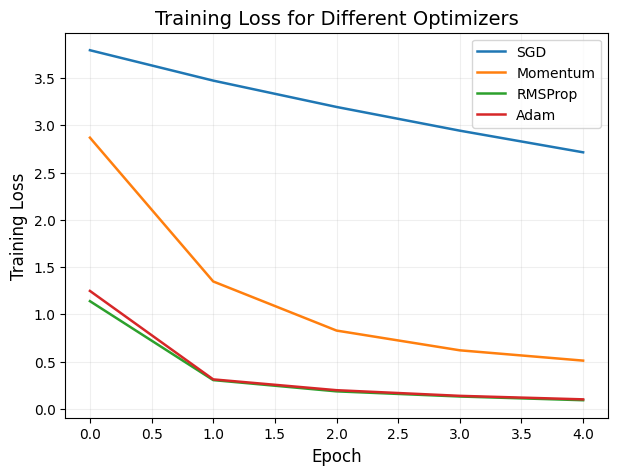

In [50]:
# ============================================================
# CELL 32 — PLOT 6
# TRAINING LOSS vs EPOCH
# ============================================================

import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))


for name, history in optimizer_histories.items():

    plt.plot(
        history.history["loss"],
        linewidth=1.8,
        label=name
    )


plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title(
    "Training Loss for Different Optimizers"
)

plt.legend()
plt.grid(alpha=0.2)


save_figure(
    "plot_6_optimizer_training_loss"
)


plt.show()
plt.close()

Saved: outputs/plot_7_optimizer_validation_accuracy.eps
Saved: outputs/plot_7_optimizer_validation_accuracy.png


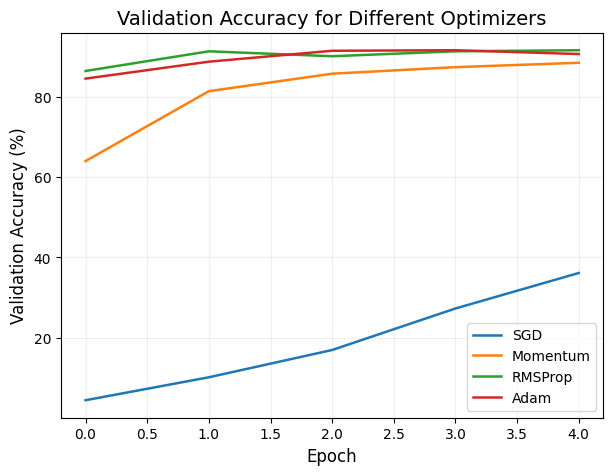

In [51]:
# ============================================================
# CELL 33 — PLOT 7
# VALIDATION ACCURACY vs EPOCH
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


plt.figure(figsize=(7, 5))


for name, history in optimizer_histories.items():

    plt.plot(
        np.array(
            history.history["val_accuracy"]
        ) * 100,

        linewidth=1.8,

        label=name
    )


plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")

plt.title(
    "Validation Accuracy for Different Optimizers"
)

plt.legend()
plt.grid(alpha=0.2)


save_figure(
    "plot_7_optimizer_validation_accuracy"
)


plt.show()
plt.close()

In [52]:
# ============================================================
# CELL 34 — BEST OPTIMIZER
# ============================================================

best_optimizer = optimizer_results_df.loc[
    optimizer_results_df[
        "Best Validation Accuracy (%)"
    ].idxmax()
]


print("Best optimizer:")
print(
    best_optimizer["Optimizer"]
)

print(
    f"Best validation accuracy: "
    f"{best_optimizer['Best Validation Accuracy (%)']:.2f}%"
)

print(
    f"Final validation accuracy: "
    f"{best_optimizer['Final Validation Accuracy (%)']:.2f}%"
)

print(
    f"Final training loss: "
    f"{best_optimizer['Final Training Loss']:.4f}"
)

Best optimizer:
RMSProp
Best validation accuracy: 91.58%
Final validation accuracy: 91.58%
Final training loss: 0.0911


In [ ]:
# ============================================================
# CELL 35 — HYPERPARAMETER TUNING
# ============================================================

# ------------------------------------------------------------
# Hyperparameter values
# ------------------------------------------------------------

learning_rates = [
    0.001,
    0.0001
]

batch_sizes = [
    16,
    32,
    64
]

dropout_rates = [
    0.0,
    0.25,
    0.5
]


# ------------------------------------------------------------
# Storage
# ------------------------------------------------------------

hyperparameter_histories = {}
hyperparameter_results = []


# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def build_hyperparameter_model(dropout_rate):

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    inputs = keras.Input(
        shape=(224, 224, 3)
    )

    x = base_model(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)

    if dropout_rate > 0:

        x = layers.Dropout(
            dropout_rate
        )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    model = keras.Model(
        inputs,
        outputs
    )

    return model


# ------------------------------------------------------------
# Helper function for recording results
# ------------------------------------------------------------

def record_hyperparameter_result(
    hyperparameter,
    value,
    history,
    training_time
):

    metrics = history.history

    required = [
        "loss",
        "accuracy",
        "val_loss",
        "val_accuracy"
    ]

    missing = [
        key for key in required
        if key not in metrics
    ]

    if missing:

        raise RuntimeError(
            f"Missing metrics for {hyperparameter} = {value}: "
            f"{missing}\n"
            f"Available metrics: {list(metrics.keys())}"
        )

    hyperparameter_results.append({

        "Hyperparameter":
            hyperparameter,

        "Value":
            value,

        "Best Validation Accuracy (%)":
            max(
                metrics["val_accuracy"]
            ) * 100,

        "Final Training Accuracy (%)":
            metrics["accuracy"][-1] * 100,

        "Final Validation Accuracy (%)":
            metrics["val_accuracy"][-1] * 100,

        "Final Training Loss":
            metrics["loss"][-1],

        "Final Validation Loss":
            metrics["val_loss"][-1],

        "Training Time (s)":
            training_time
    })


# ============================================================
# 1. LEARNING RATE EXPERIMENT
# ============================================================

for lr in learning_rates:

    print("\n" + "=" * 60)
    print("Learning Rate:", lr)
    print("=" * 60)

    experiment_name = (
        f"hyperparameter_lr_{lr}"
        .replace(".", "_")
    )

    exp_dir = os.path.join(
        CHECKPOINT_DIR,
        experiment_name
    )

    os.makedirs(
        exp_dir,
        exist_ok=True
    )

    checkpoint_path = os.path.join(
        exp_dir,
        "best_model.weights.h5"
    )

    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )

    model = build_hyperparameter_model(
        dropout_rate=0.0
    )

    model.compile(
        optimizer=keras.optimizers.RMSprop(
            learning_rate=lr
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    start_time = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1,
        callbacks=[
            checkpoint_callback
        ]
    )

    training_time = (
        time.time() - start_time
    )

    key = f"Learning Rate = {lr}"

    hyperparameter_histories[key] = history

    record_hyperparameter_result(
        "Learning Rate",
        lr,
        history,
        training_time
    )

    del model

    tf.keras.backend.clear_session()
    gc.collect()


# ============================================================
# 2. BATCH SIZE EXPERIMENT
# ============================================================

for batch_size in batch_sizes:

    print("\n" + "=" * 60)
    print("Batch Size:", batch_size)
    print("=" * 60)

    experiment_name = (
        f"hyperparameter_batch_{batch_size}"
    )

    exp_dir = os.path.join(
        CHECKPOINT_DIR,
        experiment_name
    )

    os.makedirs(
        exp_dir,
        exist_ok=True
    )

    checkpoint_path = os.path.join(
        exp_dir,
        "best_model.weights.h5"
    )

    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )

    train_batch_ds = make_dataset(
        train_raw,
        batch_size=batch_size,
        shuffle=True
    )

    val_batch_ds = make_dataset(
        val_raw,
        batch_size=batch_size,
        shuffle=False
    )

    model = build_hyperparameter_model(
        dropout_rate=0.0
    )

    model.compile(
        optimizer=keras.optimizers.RMSprop(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    start_time = time.time()

    history = model.fit(
        train_batch_ds,
        validation_data=val_batch_ds,
        epochs=EPOCHS,
        verbose=1,
        callbacks=[
            checkpoint_callback
        ]
    )

    training_time = (
        time.time() - start_time
    )

    key = f"Batch Size = {batch_size}"

    hyperparameter_histories[key] = history

    record_hyperparameter_result(
        "Batch Size",
        batch_size,
        history,
        training_time
    )

    del model

    tf.keras.backend.clear_session()
    gc.collect()


# ============================================================
# 3. DROPOUT EXPERIMENT
# ============================================================

for dropout_rate in dropout_rates:

    print("\n" + "=" * 60)
    print("Dropout:", dropout_rate)
    print("=" * 60)

    experiment_name = (
        f"hyperparameter_dropout_{str(dropout_rate).replace('.', '_')}"
    )

    exp_dir = os.path.join(
        CHECKPOINT_DIR,
        experiment_name
    )

    os.makedirs(
        exp_dir,
        exist_ok=True
    )

    checkpoint_path = os.path.join(
        exp_dir,
        "best_model.weights.h5"
    )

    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )

    model = build_hyperparameter_model(
        dropout_rate=dropout_rate
    )

    model.compile(
        optimizer=keras.optimizers.RMSprop(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    start_time = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1,
        callbacks=[
            checkpoint_callback
        ]
    )

    training_time = (
        time.time() - start_time
    )

    key = f"Dropout = {dropout_rate}"

    hyperparameter_histories[key] = history

    record_hyperparameter_result(
        "Dropout",
        dropout_rate,
        history,
        training_time
    )

    del model

    tf.keras.backend.clear_session()
    gc.collect()


# ============================================================
# RESULTS TABLE
# ============================================================

hyperparameter_df = pd.DataFrame(
    hyperparameter_results
)

display(
    hyperparameter_df
)


# ============================================================
# SAVE RESULTS
# ============================================================

hyperparameter_csv_path = os.path.join(
    RESULTS_DIR,
    "hyperparameter_results.csv"
)

hyperparameter_df.to_csv(
    hyperparameter_csv_path,
    index=False
)

print(
    "Hyperparameter results saved to:",
    hyperparameter_csv_path
)


Learning Rate: 0.001
Epoch 1/5
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5368 - loss: 1.9831
Epoch 1: val_accuracy improved from None to 0.86413, saving model to /content/drive/MyDrive/Lab5/checkpoints/hyperparameter_lr_0_001/best_model.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Lab5/checkpoints/hyperparameter_lr_0_001/best_model.weights.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 258ms/step - accuracy: 0.7344 - loss: 1.1603 - val_accuracy: 0.8641 - val_loss: 0.4668
Epoch 2/5
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9238 - loss: 0.3126
Epoch 2: val_accuracy improved from 0.86413 to 0.90082, saving model to /content/drive/MyDrive/Lab5/checkpoints/hyperparameter_lr_0_001/best_model.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/Lab5/checkpoints/hyperparameter_lr_0_001/best_model.weights.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 196ms/step - accuracy: 0.9246 - loss: 0.2943 - val_accuracy: 0.9008 - val_loss: 0.3241
Epoch 3/5
92/92 ━━━

In [ ]:
# ============================================================
# CELL 36 — SAVE HYPERPARAMETER RESULTS
# ============================================================

import os
import pandas as pd


hyperparameter_csv_path = os.path.join(
    OUTPUT_DIR,
    "hyperparameter_results.csv"
)

hyperparameter_df.to_csv(
    hyperparameter_csv_path,
    index=False
)

print("Results saved to:")
print(hyperparameter_csv_path)


In [ ]:
# ============================================================
# CELL 37 — PLOT 8
# LEARNING RATE COMPARISON
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


lr_df = hyperparameter_df[
    hyperparameter_df["Hyperparameter"] == "Learning Rate"
]


plt.figure(figsize=(7, 5))

plt.plot(
    lr_df["Value"].astype(float),
    lr_df["Best Validation Accuracy (%)"],
    marker="o",
    linewidth=1.8
)

plt.xlabel("Learning Rate")
plt.ylabel("Best Validation Accuracy (%)")

plt.title(
    "Effect of Learning Rate on Validation Accuracy"
)

plt.xscale("log")

plt.grid(alpha=0.2)

save_figure(
    "plot_8_learning_rate"
)

plt.show()
plt.close()

In [ ]:
# ============================================================
# CELL 38 — PLOT 9
# BATCH SIZE COMPARISON
# ============================================================

import matplotlib.pyplot as plt


batch_df = hyperparameter_df[
    hyperparameter_df["Hyperparameter"] == "Batch Size"
]


plt.figure(figsize=(7, 5))

plt.plot(
    batch_df["Value"].astype(float),
    batch_df["Best Validation Accuracy (%)"],
    marker="o",
    linewidth=1.8
)

plt.xlabel("Batch Size")
plt.ylabel("Best Validation Accuracy (%)")

plt.title(
    "Effect of Batch Size on Validation Accuracy"
)

plt.xticks([16, 32, 64])

plt.grid(alpha=0.2)

save_figure(
    "plot_9_batch_size"
)

plt.show()
plt.close()

In [ ]:
# ============================================================
# CELL 39 — PLOT 10
# DROPOUT COMPARISON
# ============================================================

import matplotlib.pyplot as plt


dropout_df = hyperparameter_df[
    hyperparameter_df["Hyperparameter"] == "Dropout"
]


plt.figure(figsize=(7, 5))

plt.plot(
    dropout_df["Value"].astype(float),
    dropout_df["Best Validation Accuracy (%)"],
    marker="o",
    linewidth=1.8
)

plt.xlabel("Dropout Rate")
plt.ylabel("Best Validation Accuracy (%)")

plt.title(
    "Effect of Dropout Rate on Validation Accuracy"
)

plt.xticks([0, 0.25, 0.5])

plt.grid(alpha=0.2)

save_figure(
    "plot_10_dropout"
)

plt.show()
plt.close()

In [ ]:
# ============================================================
# CELL 40 — SELECTED HYPERPARAMETERS
# ============================================================

import pandas as pd


selected_configuration = {
    "Optimizer": "RMSProp",
    "Learning Rate": 0.001,
    "Batch Size": 32,
    "Dropout": 0.0
}


selected_df = pd.DataFrame(
    [selected_configuration]
)


display(selected_df)

In [ ]:
# ============================================================
# SAVE SELECTED CONFIGURATION
# ============================================================

import os


selected_config_path = os.path.join(
    OUTPUT_DIR,
    "selected_hyperparameters.csv"
)

selected_df.to_csv(
    selected_config_path,
    index=False
)

print("Selected configuration saved to:")
print(selected_config_path)

In [ ]:
# Persistent checkpoint for this experiment.
_callbacks, _paths = create_persistent_callbacks("feature_extraction")
mark_experiment_status("feature_extraction", "running")

# ============================================================
# CELL 41 — TRANSFER LEARNING COMPARISON
# ============================================================

import os
import gc
import time
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2


# ------------------------------------------------------------
# Configuration selected from previous experiments
# ------------------------------------------------------------

FINAL_LR = 0.001
FINAL_BATCH_SIZE = 32
FINAL_DROPOUT = 0.0


transfer_histories = {}
transfer_results = []


# ------------------------------------------------------------
# Two transfer-learning strategies
# ------------------------------------------------------------

transfer_configs = {

    "Feature Extraction": {
        "fine_tune": False
    },

    "Fine-Tuning": {
        "fine_tune": True
    }
}


# ------------------------------------------------------------
# Train both approaches
# ------------------------------------------------------------

for name, config in transfer_configs.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)


    # --------------------------------------------------------
    # Fresh pretrained MobileNetV2
    # --------------------------------------------------------

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )


    # --------------------------------------------------------
    # Feature Extraction
    # --------------------------------------------------------

    if not config["fine_tune"]:

        base_model.trainable = False


    # --------------------------------------------------------
    # Fine-Tuning
    # --------------------------------------------------------

    else:

        base_model.trainable = True

        # Freeze most of the network
        # and fine-tune only the last 20 layers

        for layer in base_model.layers[:-20]:
            layer.trainable = False


    # --------------------------------------------------------
    # Build classifier
    # --------------------------------------------------------

    inputs = keras.Input(
        shape=(224, 224, 3)
    )

    x = base_model(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    model = keras.Model(
        inputs,
        outputs
    )


    # --------------------------------------------------------
    # Compile
    # --------------------------------------------------------

    model.compile(
        optimizer=keras.optimizers.RMSprop(
            learning_rate=FINAL_LR
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )


    # --------------------------------------------------------
    # Count trainable parameters
    # --------------------------------------------------------

    trainable_params = np.sum([
        np.prod(v.shape)
        for v in model.trainable_variables
    ])


    total_params = model.count_params()


    print(
        "Trainable parameters:",
        trainable_params
    )

    print(
        "Total parameters:",
        total_params
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    start_time = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    ,
    callbacks=_callbacks)

    training_time = time.time() - start_time


    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    transfer_histories[name] = history


    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    transfer_results.append({

        "Transfer Learning Method": name,

        "Trainable Parameters": int(
            trainable_params
        ),

        "Total Parameters": int(
            total_params
        ),

        "Best Validation Accuracy (%)":
            max(
                history.history["val_accuracy"]
            ) * 100,

        "Final Training Accuracy (%)":
            history.history["accuracy"][-1] * 100,

        "Final Validation Accuracy (%)":
            history.history["val_accuracy"][-1] * 100,

        "Final Training Loss":
            history.history["loss"][-1],

        "Final Validation Loss":
            history.history["val_loss"][-1],

        "Training Time (s)":
            training_time
    })


    # --------------------------------------------------------
    # Clear memory
    # --------------------------------------------------------

    del model
    del base_model

    tf.keras.backend.clear_session()
    gc.collect()


# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

transfer_results_df = pd.DataFrame(
    transfer_results
)

display(transfer_results_df)

if "history" in globals():
    save_training_history(history, _paths, {"experiment": "feature_extraction"})
    mark_experiment_status("feature_extraction", "completed")


In [ ]:
# ============================================================
# CELL 42 — SAVE TRANSFER LEARNING RESULTS
# ============================================================

import os


transfer_csv_path = os.path.join(
    OUTPUT_DIR,
    "transfer_learning_results.csv"
)

transfer_results_df.to_csv(
    transfer_csv_path,
    index=False
)

print("Results saved to:")
print(transfer_csv_path)

Saved: outputs/transfer_learning_validation_accuracy.eps
Saved: outputs/transfer_learning_validation_accuracy.png


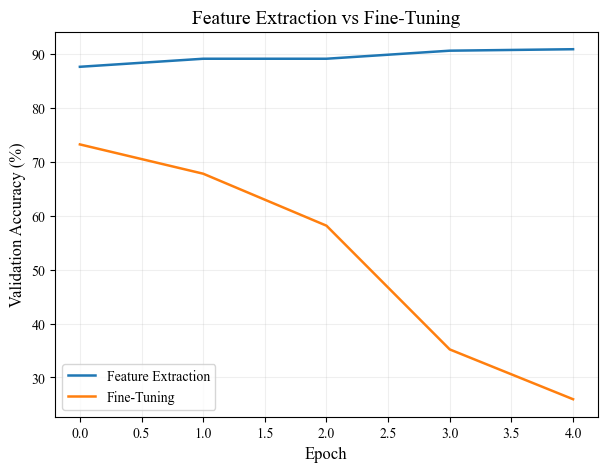

In [ ]:
# ============================================================
# CELL 43 — TRANSFER LEARNING VALIDATION ACCURACY
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))


for name, history in transfer_histories.items():

    plt.plot(
        np.array(
            history.history["val_accuracy"]
        ) * 100,

        linewidth=1.8,

        label=name
    )


plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")

plt.title(
    "Feature Extraction vs Fine-Tuning"
)

plt.legend()
plt.grid(alpha=0.2)

save_figure(
    "transfer_learning_validation_accuracy"
)

plt.show()
plt.close()

Saved: outputs/transfer_learning_training_loss.eps
Saved: outputs/transfer_learning_training_loss.png


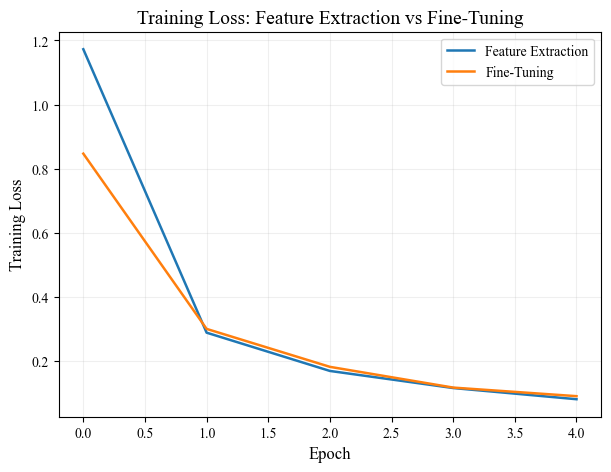

In [ ]:
# ============================================================
# CELL 44 — TRANSFER LEARNING TRAINING LOSS
# ============================================================

import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))


for name, history in transfer_histories.items():

    plt.plot(
        history.history["loss"],
        linewidth=1.8,
        label=name
    )


plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title(
    "Training Loss: Feature Extraction vs Fine-Tuning"
)

plt.legend()
plt.grid(alpha=0.2)

save_figure(
    "transfer_learning_training_loss"
)

plt.show()
plt.close()

In [ ]:
# ============================================================
# CELL 45 — BEST TRANSFER LEARNING METHOD
# ============================================================

best_transfer = transfer_results_df.loc[
    transfer_results_df[
        "Best Validation Accuracy (%)"
    ].idxmax()
]


print("Best transfer-learning method:")
print(
    best_transfer[
        "Transfer Learning Method"
    ]
)

print(
    f"Best validation accuracy: "
    f"{best_transfer['Best Validation Accuracy (%)']:.2f}%"
)

print(
    f"Trainable parameters: "
    f"{best_transfer['Trainable Parameters']:,}"
)

print(
    f"Training time: "
    f"{best_transfer['Training Time (s)']:.2f} seconds"
)

Best transfer-learning method:
Feature Extraction
Best validation accuracy: 90.90%
Trainable parameters: 47,397
Training time: 88.26 seconds


In [ ]:
# Persistent checkpoint for this experiment.
_callbacks, _paths = create_persistent_callbacks("experiment_cell_056")
mark_experiment_status("experiment_cell_056", "running")

# ============================================================
# CELL 46 — CORRECT FINE-TUNING EXPERIMENT
# ============================================================

import os
import gc
import time
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2


# ------------------------------------------------------------
# Fine-tuning learning rate from the manual
# ------------------------------------------------------------

FINE_TUNE_LR = 0.0001

FINE_TUNE_EPOCHS = EPOCHS


# ------------------------------------------------------------
# Load fresh pretrained MobileNetV2
# ------------------------------------------------------------

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)


# ------------------------------------------------------------
# Freeze most layers
# ------------------------------------------------------------

base_model.trainable = True


# Keep only the final 20 layers trainable
for layer in base_model.layers[:-20]:

    layer.trainable = False


# ------------------------------------------------------------
# Build model
# ------------------------------------------------------------

inputs = keras.Input(
    shape=(224, 224, 3)
)

x = base_model(
    inputs,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)


fine_tune_model = keras.Model(
    inputs,
    outputs
)


# ------------------------------------------------------------
# Compile with SMALL learning rate
# ------------------------------------------------------------

fine_tune_model.compile(
    optimizer=keras.optimizers.RMSprop(
        learning_rate=FINE_TUNE_LR
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)


# ------------------------------------------------------------
# Count parameters
# ------------------------------------------------------------

trainable_params = np.sum([
    np.prod(v.shape)
    for v in fine_tune_model.trainable_variables
])

total_params = fine_tune_model.count_params()


print(
    "Trainable parameters:",
    f"{trainable_params:,}"
)

print(
    "Total parameters:",
    f"{total_params:,}"
)

print(
    "Fine-tuning learning rate:",
    FINE_TUNE_LR
)


# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

start_time = time.time()


fine_tune_history = fine_tune_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    verbose=1
,
    callbacks=_callbacks)


fine_tune_time = time.time() - start_time


print(
    f"\nTraining time: "
    f"{fine_tune_time:.2f} seconds"
)

if "history" in globals():
    save_training_history(history, _paths, {"experiment": "experiment_cell_056"})
    mark_experiment_status("experiment_cell_056", "completed")


Trainable parameters: 1,253,477
Total parameters: 2,305,381
Fine-tuning learning rate: 0.0001
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 35s 176ms/step - accuracy: 0.6933 - loss: 1.3763 - val_accuracy: 0.8438 - val_loss: 0.5683
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 122ms/step - accuracy: 0.9263 - loss: 0.3080 - val_accuracy: 0.8764 - val_loss: 0.4314
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 122ms/step - accuracy: 0.9718 - loss: 0.1407 - val_accuracy: 0.8886 - val_loss: 0.3685
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - accuracy: 0.9915 - loss: 0.0701 - val_accuracy: 0.9022 - val_loss: 0.3308
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - accuracy: 0.9976 - loss: 0.0348 - val_accuracy: 0.8954 - val_loss: 0.3275

Training time: 85.27 seconds


In [ ]:
# ============================================================
# CELL 47 — SAVE FINE-TUNING RESULTS
# ============================================================

import os
import pandas as pd


fine_tune_results = pd.DataFrame([
    {
        "Method": "Fine-Tuning",

        "Learning Rate": FINE_TUNE_LR,

        "Trainable Parameters":
            int(trainable_params),

        "Total Parameters":
            int(total_params),

        "Best Validation Accuracy (%)":
            max(
                fine_tune_history.history[
                    "val_accuracy"
                ]
            ) * 100,

        "Final Training Accuracy (%)":
            fine_tune_history.history[
                "accuracy"
            ][-1] * 100,

        "Final Validation Accuracy (%)":
            fine_tune_history.history[
                "val_accuracy"
            ][-1] * 100,

        "Final Training Loss":
            fine_tune_history.history[
                "loss"
            ][-1],

        "Final Validation Loss":
            fine_tune_history.history[
                "val_loss"
            ][-1],

        "Training Time (s)":
            fine_tune_time
    }
])


fine_tune_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "correct_fine_tuning_results.csv"
    ),
    index=False
)


display(fine_tune_results)

,Method,Learning Rate,Trainable Parameters,Total Parameters,Best Validation Accuracy (%),Final Training Accuracy (%),Final Validation Accuracy (%),Final Training Loss,Final Validation Loss,Training Time (s)
0,Fine-Tuning,0.0001,1253477,2305381,90.217394,99.762231,89.538044,0.034841,0.327515,85.268207


Saved: outputs/plot_11_feature_extraction_vs_fine_tuning.eps
Saved: outputs/plot_11_feature_extraction_vs_fine_tuning.png


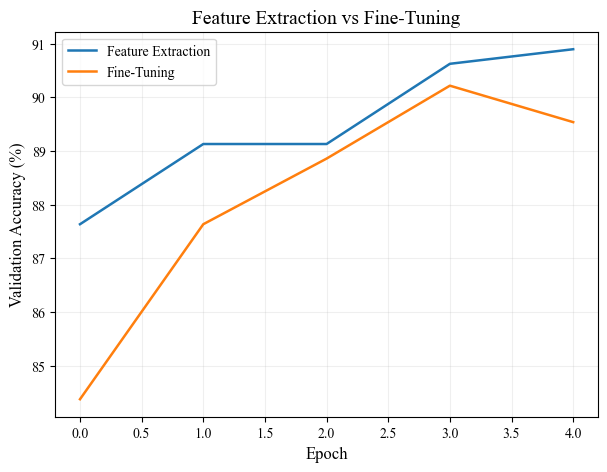

In [ ]:
# ============================================================
# CELL 48 — PLOT 11
# FEATURE EXTRACTION vs FINE-TUNING
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))


# Feature Extraction
plt.plot(
    np.array(
        transfer_histories[
            "Feature Extraction"
        ].history["val_accuracy"]
    ) * 100,

    linewidth=1.8,

    label="Feature Extraction"
)


# Correct Fine-Tuning
plt.plot(
    np.array(
        fine_tune_history.history[
            "val_accuracy"
        ]
    ) * 100,

    linewidth=1.8,

    label="Fine-Tuning"
)


plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")

plt.title(
    "Feature Extraction vs Fine-Tuning"
)

plt.legend()
plt.grid(alpha=0.2)


save_figure(
    "plot_11_feature_extraction_vs_fine_tuning"
)


plt.show()
plt.close()

Saved: outputs/plot_12_transfer_learning_loss.eps
Saved: outputs/plot_12_transfer_learning_loss.png


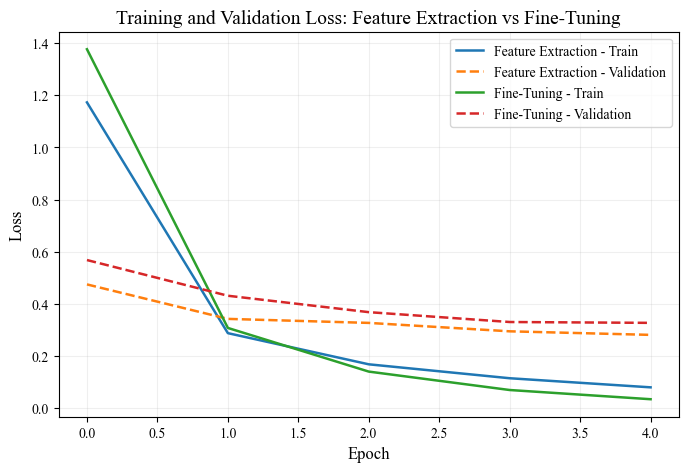

In [ ]:
# ============================================================
# CELL 49 — PLOT 12
# TRAINING AND VALIDATION LOSS
# ============================================================

import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))


# ------------------------------------------------------------
# Feature Extraction
# ------------------------------------------------------------

plt.plot(
    transfer_histories[
        "Feature Extraction"
    ].history["loss"],

    linewidth=1.8,

    label="Feature Extraction - Train"
)


plt.plot(
    transfer_histories[
        "Feature Extraction"
    ].history["val_loss"],

    linestyle="--",

    linewidth=1.8,

    label="Feature Extraction - Validation"
)


# ------------------------------------------------------------
# Fine-Tuning
# ------------------------------------------------------------

plt.plot(
    fine_tune_history.history["loss"],

    linewidth=1.8,

    label="Fine-Tuning - Train"
)


plt.plot(
    fine_tune_history.history["val_loss"],

    linestyle="--",

    linewidth=1.8,

    label="Fine-Tuning - Validation"
)


plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss: "
    "Feature Extraction vs Fine-Tuning"
)

plt.legend()
plt.grid(alpha=0.2)


save_figure(
    "plot_12_transfer_learning_loss"
)


plt.show()
plt.close()

In [ ]:
# ============================================================
# CELL 50 — PREPARE 5-FOLD CROSS-VALIDATION
# ============================================================

import os
import gc
import time
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

from sklearn.model_selection import StratifiedKFold


# ------------------------------------------------------------
# Get labels ONLY
# We do NOT load the images into NumPy.
# ------------------------------------------------------------

cv_labels = np.array([
    label.numpy()
    for _, label in train_raw
])


print("Number of training samples:", len(cv_labels))
print("Number of classes:", len(np.unique(cv_labels)))


# ------------------------------------------------------------
# Create 5 folds
# ------------------------------------------------------------

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)


folds = list(
    skf.split(
        np.zeros(len(cv_labels)),
        cv_labels
    )
)


print("\n5 folds created.")

for fold_number, (train_indices, val_indices) in enumerate(
    folds,
    start=1
):

    print(
        f"Fold {fold_number}: "
        f"Train = {len(train_indices)}, "

        f"Validation = {len(val_indices)}"
    )

Number of training samples: 2944
Number of classes: 37

5 folds created.
Fold 1: Train = 2355, Validation = 589
Fold 2: Train = 2355, Validation = 589
Fold 3: Train = 2355, Validation = 589
Fold 4: Train = 2355, Validation = 589
Fold 5: Train = 2356, Validation = 588


In [ ]:
# ============================================================
# CELL 51 — CREATE DATASET FOR A SPECIFIC FOLD
# ============================================================

def create_fold_dataset(
    raw_dataset,
    indices,
    batch_size,
    shuffle=False
):

    # Convert selected indices into a TensorFlow tensor
    indices_tensor = tf.constant(
        indices,
        dtype=tf.int64
    )


    # Create a lookup table:
    # selected index -> 1
    keys = indices_tensor

    values = tf.ones_like(
        indices_tensor,
        dtype=tf.int64
    )


    table = tf.lookup.StaticHashTable(
        tf.lookup.KeyValueTensorInitializer(
            keys,
            values
        ),
        default_value=0
    )


    # Enumerate dataset so every image has an index
    dataset = raw_dataset.enumerate()


    # Keep only requested indices
    dataset = dataset.filter(
        lambda index, data:
        table.lookup(index) == 1
    )


    # Remove enumeration index
    dataset = dataset.map(
        lambda index, data: data,
        num_parallel_calls=tf.data.AUTOTUNE
    )


    # Normal preprocessing
    dataset = dataset.map(
        preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )


    if shuffle:

        dataset = dataset.shuffle(
            1000,
            seed=SEED
        )


    dataset = dataset.batch(
        batch_size
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )


    return dataset

In [ ]:
# ============================================================
# CELL 52 — MODEL BUILDER FOR CROSS-VALIDATION
# ============================================================

def build_cv_model(
    initialization="normal",
    fine_tune=False
):

    # --------------------------------------------------------
    # MobileNetV2
    # --------------------------------------------------------

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )


    # --------------------------------------------------------
    # Freeze / Fine-Tune
    # --------------------------------------------------------

    if fine_tune:

        base_model.trainable = True

        # Freeze all but last 20 layers
        for layer in base_model.layers[:-20]:

            layer.trainable = False

    else:

        base_model.trainable = False


    # --------------------------------------------------------
    # Input
    # --------------------------------------------------------

    inputs = keras.Input(
        shape=(224, 224, 3)
    )


    x = base_model(
        inputs,
        training=False
    )


    x = layers.GlobalAveragePooling2D()(x)


    # --------------------------------------------------------
    # Classifier initialization
    # --------------------------------------------------------

    if initialization == "zero":

        outputs = layers.Dense(
            NUM_CLASSES,
            activation="softmax",
            kernel_initializer=keras.initializers.Zeros()
        )(x)

    else:

        outputs = layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )(x)


    model = keras.Model(
        inputs,
        outputs
    )


    return model

In [ ]:
# ============================================================
# CELL 53 — CV CONFIGURATIONS
# ============================================================

cv_configs = {

    "C1 - Baseline": {
        "initialization": "normal",
        "fine_tune": False,
        "learning_rate": 0.001
    },

    "C2 - Zero Initialization": {
        "initialization": "zero",
        "fine_tune": False,
        "learning_rate": 0.001
    },

    "C3 - Fine-Tuning": {
        "initialization": "normal",
        "fine_tune": True,
        "learning_rate": 0.0001
    }
}


display(
    pd.DataFrame(cv_configs).T
)

,initialization,fine_tune,learning_rate
C1 - Baseline,normal,False,0.001
C2 - Zero Initialization,zero,False,0.001
C3 - Fine-Tuning,normal,True,0.0001


In [ ]:
# ============================================================
# CELL 51 — FIXED FOLD DATASET
# ============================================================

def create_fold_dataset(
    raw_dataset,
    indices,
    batch_size,
    shuffle=False
):

    # --------------------------------------------------------
    # Create lookup table for selected indices
    # --------------------------------------------------------

    indices_tensor = tf.constant(
        indices,
        dtype=tf.int64
    )

    values = tf.ones_like(
        indices_tensor,
        dtype=tf.int64
    )

    table = tf.lookup.StaticHashTable(
        tf.lookup.KeyValueTensorInitializer(
            indices_tensor,
            values
        ),
        default_value=0
    )


    # --------------------------------------------------------
    # Add index to every sample
    # --------------------------------------------------------

    dataset = raw_dataset.enumerate()


    # --------------------------------------------------------
    # Keep only samples belonging to this fold
    # --------------------------------------------------------

    dataset = dataset.filter(
        lambda index, data:
        table.lookup(index) == 1
    )


    # Remove index
    dataset = dataset.map(
        lambda index, data: data,
        num_parallel_calls=tf.data.AUTOTUNE
    )


    # --------------------------------------------------------
    # Preprocess
    # --------------------------------------------------------

    dataset = dataset.map(
        preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )


    # --------------------------------------------------------
    # Shuffle
    # --------------------------------------------------------

    if shuffle:

        dataset = dataset.shuffle(
            1000,
            seed=SEED,
            reshuffle_each_iteration=True
        )


    # --------------------------------------------------------
    # IMPORTANT:
    # Repeat forever so Keras never runs out of data
    # --------------------------------------------------------

    dataset = dataset.repeat()


    # --------------------------------------------------------
    # Batch
    # --------------------------------------------------------

    dataset = dataset.batch(
        batch_size
    )


    # --------------------------------------------------------
    # Prefetch
    # --------------------------------------------------------

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )


    return dataset

In [ ]:
# Persistent checkpoint for this experiment.
_callbacks, _paths = create_persistent_callbacks("experiment_cell_065")
mark_experiment_status("experiment_cell_065", "running")

# ============================================================
# CELL 54 — RUN 5-FOLD CROSS-VALIDATION
# FIXED VERSION
# ============================================================

cv_results = []


for config_name, config in cv_configs.items():

    print("\n")
    print("#" * 70)
    print(config_name)
    print("#" * 70)


    for fold_number, (train_indices, val_indices) in enumerate(
        folds,
        start=1
    ):

        print("\n" + "-" * 60)

        print(
            f"{config_name} | "
            f"Fold {fold_number}/5"
        )

        print("-" * 60)


        # ----------------------------------------------------
        # Number of samples in each fold
        # ----------------------------------------------------

        num_train_samples = len(train_indices)

        num_val_samples = len(val_indices)


        # Number of batches per epoch
        steps_per_epoch = int(
            np.ceil(
                num_train_samples / 32
            )
        )

        validation_steps = int(
            np.ceil(
                num_val_samples / 32
            )
        )


        print(
            "Training samples:",
            num_train_samples
        )

        print(
            "Validation samples:",
            num_val_samples
        )

        print(
            "Steps per epoch:",
            steps_per_epoch
        )

        print(
            "Validation steps:",
            validation_steps
        )


        # ----------------------------------------------------
        # Create fold datasets
        # ----------------------------------------------------

        fold_train_ds = create_fold_dataset(
            train_raw,
            train_indices,
            batch_size=32,
            shuffle=True
        )


        fold_val_ds = create_fold_dataset(
            train_raw,
            val_indices,
            batch_size=32,
            shuffle=False
        )


        # ----------------------------------------------------
        # Build fresh model
        # ----------------------------------------------------

        model = build_cv_model(
            initialization=config["initialization"],
            fine_tune=config["fine_tune"]
        )


        # ----------------------------------------------------
        # Compile
        # ----------------------------------------------------

        model.compile(

            optimizer=keras.optimizers.RMSprop(
                learning_rate=config["learning_rate"]
            ),

            loss="sparse_categorical_crossentropy",

            metrics=["accuracy"]
        )


        # ----------------------------------------------------
        # Train
        # ----------------------------------------------------

        start_time = time.time()


        history = model.fit(

            fold_train_ds,

            validation_data=fold_val_ds,

            epochs=EPOCHS,

            steps_per_epoch=steps_per_epoch,

            validation_steps=validation_steps,

            verbose=1
        ,
    callbacks=_callbacks)


        training_time = time.time() - start_time


        # ----------------------------------------------------
        # Best validation accuracy
        # ----------------------------------------------------

        best_val_accuracy = max(
            history.history["val_accuracy"]
        ) * 100


        # ----------------------------------------------------
        # Final validation accuracy
        # ----------------------------------------------------

        final_val_accuracy = (
            history.history["val_accuracy"][-1]
            * 100
        )


        # ----------------------------------------------------
        # Save fold result
        # ----------------------------------------------------

        cv_results.append({

            "Configuration": config_name,

            "Fold": fold_number,

            "Best Validation Accuracy (%)":
                best_val_accuracy,

            "Final Validation Accuracy (%)":
                final_val_accuracy,

            "Training Time (s)":
                training_time
        })


        print(
            f"Best validation accuracy: "
            f"{best_val_accuracy:.2f}%"
        )


        # ----------------------------------------------------
        # Clear memory
        # ----------------------------------------------------

        del model
        del fold_train_ds
        del fold_val_ds

        tf.keras.backend.clear_session()

        gc.collect()


# ------------------------------------------------------------
# Results DataFrame
# ------------------------------------------------------------

cv_results_df = pd.DataFrame(
    cv_results
)


display(cv_results_df)

if "history" in globals():
    save_training_history(history, _paths, {"experiment": "experiment_cell_065"})
    mark_experiment_status("experiment_cell_065", "completed")




######################################################################
C1 - Baseline
######################################################################

------------------------------------------------------------
C1 - Baseline | Fold 1/5
------------------------------------------------------------
Training samples: 2355
Validation samples: 589
Steps per epoch: 74
Validation steps: 19
Epoch 1/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 33s 276ms/step - accuracy: 0.7027 - loss: 1.3064 - val_accuracy: 0.8750 - val_loss: 0.5041
Epoch 2/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 22s 294ms/step - accuracy: 0.9189 - loss: 0.3322 - val_accuracy: 0.9128 - val_loss: 0.3252
Epoch 3/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 22s 294ms/step - accuracy: 0.9476 - loss: 0.1934 - val_accuracy: 0.9128 - val_loss: 0.2714
Epoch 4/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 17s 234ms/step - accuracy: 0.9734 - loss: 0.1281 - val_accuracy: 0.9095 - val_loss: 0.2430
Epoch 5/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 239ms/step - accuracy: 0.9823 - loss: 0.0898 - val_ac

,Configuration,Fold,Best Validation Accuracy (%),Final Validation Accuracy (%),Training Time (s)
0,C1 - Baseline,1,91.776317,91.776317,111.120483
1,C1 - Baseline,2,91.611844,90.460527,95.382056
2,C1 - Baseline,3,91.940790,91.282892,98.444164
3,C1 - Baseline,4,91.118419,91.118419,99.508641
4,C1 - Baseline,5,91.282892,91.282892,98.860876
5,C2 - Zero Initialization,1,92.763156,92.105263,93.851117
6,C2 - Zero Initialization,2,91.282892,91.118419,96.438579
7,C2 - Zero Initialization,3,91.940790,91.940790,145.597430
8,C2 - Zero Initialization,4,90.789473,90.789473,99.238364
9,C2 - Zero Initialization,5,91.776317,91.776317,96.709828


In [ ]:
# ============================================================
# CELL 55 — 5-FOLD CV SUMMARY
# ============================================================

cv_summary = (
    cv_results_df
    .groupby("Configuration")["Best Validation Accuracy (%)"]
    .agg(
        Mean="mean",
        SD="std"
    )
    .reset_index()
)

display(cv_summary)

,Configuration,Mean,SD
0,C1 - Baseline,91.546053,0.341062
1,C2 - Zero Initialization,91.710526,0.741045
2,C3 - Fine-Tuning,90.197369,0.897851


In [ ]:
# ============================================================
# CELL 56 — ADD TRAINING TIME
# ============================================================

time_summary = (
    cv_results_df
    .groupby("Configuration")["Training Time (s)"]
    .mean()
    .reset_index()
    .rename(
        columns={
            "Training Time (s)": "Mean Training Time (s)"
        }
    )
)

cv_summary = cv_summary.merge(
    time_summary,
    on="Configuration"
)

display(cv_summary)

,Configuration,Mean,SD,Mean Training Time (s)
0,C1 - Baseline,91.546053,0.341062,100.663244
1,C2 - Zero Initialization,91.710526,0.741045,106.367064
2,C3 - Fine-Tuning,90.197369,0.897851,101.536611


In [ ]:
# ============================================================
# CELL 57 — SAVE CV RESULTS
# ============================================================

import os

cv_results_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "5_fold_cv_fold_results.csv"
    ),
    index=False
)

cv_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "5_fold_cv_summary.csv"
    ),
    index=False
)

print("5-fold CV results saved.")

5-fold CV results saved.


Saved: outputs/plot_13_5_fold_cross_validation.eps
Saved: outputs/plot_13_5_fold_cross_validation.png


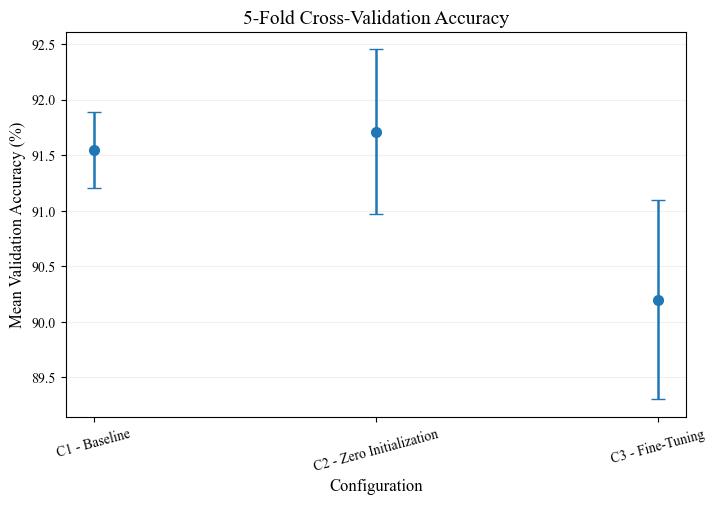

In [ ]:
# ============================================================
# CELL 58 — PLOT 13
# 5-FOLD CROSS-VALIDATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

x = np.arange(len(cv_summary))

plt.errorbar(
    x,
    cv_summary["Mean"],
    yerr=cv_summary["SD"],
    fmt="o",
    capsize=5,
    linewidth=1.8,
    markersize=7
)

plt.xticks(
    x,
    cv_summary["Configuration"],
    rotation=15
)

plt.xlabel("Configuration")
plt.ylabel("Mean Validation Accuracy (%)")

plt.title(
    "5-Fold Cross-Validation Accuracy"
)

plt.grid(
    alpha=0.2,
    axis="y"
)

save_figure(
    "plot_13_5_fold_cross_validation"
)

plt.show()
plt.close()

In [ ]:
# ============================================================
# CELL 59 — FINAL CONFIGURATION
# ============================================================

best_cv = cv_summary.loc[
    cv_summary["Mean"].idxmax()
]

print("FINAL CONFIGURATION")
print("=" * 50)

print(
    "Configuration:",
    best_cv["Configuration"]
)

print(
    f"Mean CV Accuracy: "
    f"{best_cv['Mean']:.2f}%"
)

print(
    f"Standard Deviation: "
    f"{best_cv['SD']:.2f}%"
)

print(
    f"Mean Training Time: "
    f"{best_cv['Mean Training Time (s)']:.2f} seconds"
)

FINAL CONFIGURATION
Configuration: C2 - Zero Initialization
Mean CV Accuracy: 91.71%
Standard Deviation: 0.74%
Mean Training Time: 106.37 seconds


In [ ]:
# ============================================================
# CELL 60 — FINAL MODEL
# ============================================================

import os
import gc
import time
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2


# ------------------------------------------------------------
# Final configuration selected by 5-fold CV
# ------------------------------------------------------------

FINAL_INITIALIZATION = "zero"
FINAL_LEARNING_RATE = 0.001
FINAL_BATCH_SIZE = 32
FINAL_DROPOUT = 0.0


print("FINAL MODEL CONFIGURATION")
print("=" * 50)
print("Initialization :", FINAL_INITIALIZATION)
print("Optimizer      : RMSProp")
print("Learning Rate  :", FINAL_LEARNING_RATE)
print("Batch Size     :", FINAL_BATCH_SIZE)
print("Dropout        :", FINAL_DROPOUT)


# ------------------------------------------------------------
# Fresh pretrained MobileNetV2
# ------------------------------------------------------------

final_base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)


# Freeze pretrained base
final_base_model.trainable = False


# ------------------------------------------------------------
# Build final model
# ------------------------------------------------------------

inputs = keras.Input(
    shape=(224, 224, 3)
)

x = final_base_model(
    inputs,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)


# Zero initialization selected by CV
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    kernel_initializer=keras.initializers.Zeros()
)(x)


final_model = keras.Model(
    inputs,
    outputs
)


# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

final_model.compile(

    optimizer=keras.optimizers.RMSprop(
        learning_rate=FINAL_LEARNING_RATE
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)


# ------------------------------------------------------------
# Model information
# ------------------------------------------------------------

print("\nTotal parameters:")
print(f"{final_model.count_params():,}")

print("\nTrainable parameters:")

trainable_params = np.sum([
    np.prod(v.shape)
    for v in final_model.trainable_variables
])

print(f"{trainable_params:,}")

FINAL MODEL CONFIGURATION
Initialization : zero
Optimizer      : RMSProp
Learning Rate  : 0.001
Batch Size     : 32
Dropout        : 0.0

Total parameters:
2,305,381

Trainable parameters:
47,397


In [ ]:
# Persistent checkpoint for this experiment.
_callbacks, _paths = create_persistent_callbacks("experiment_cell_072")
mark_experiment_status("experiment_cell_072", "running")

# ============================================================
# CELL 61 — TRAIN FINAL MODEL
# ============================================================

start_time = time.time()


final_history = final_model.fit(

    train_ds,

    epochs=EPOCHS,

    verbose=1
,
    callbacks=_callbacks)


final_training_time = time.time() - start_time


print(
    f"\nFinal training time: "
    f"{final_training_time:.2f} seconds"
)


print(
    f"Final training accuracy: "
    f"{final_history.history['accuracy'][-1] * 100:.2f}%"
)


print(
    f"Final training loss: "
    f"{final_history.history['loss'][-1]:.4f}"
)

if "history" in globals():
    save_training_history(history, _paths, {"experiment": "experiment_cell_072"})
    mark_experiment_status("experiment_cell_072", "completed")


Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 28s 113ms/step - accuracy: 0.8067 - loss: 1.0204
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 28s 66ms/step - accuracy: 0.9351 - loss: 0.2607
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.9630 - loss: 0.1566
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.9755 - loss: 0.1056
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.9837 - loss: 0.0767

Final training time: 84.32 seconds
Final training accuracy: 98.37%
Final training loss: 0.0767


In [ ]:
# ============================================================
# CELL 62 — FINAL TEST EVALUATION
# ============================================================

test_loss, test_accuracy = final_model.evaluate(
    test_ds,
    verbose=1
)


print("\nFINAL TEST RESULTS")
print("=" * 50)

print(
    f"Test Loss: "
    f"{test_loss:.4f}"
)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

115/115 ━━━━━━━━━━━━━━━━━━━━ 28s 196ms/step - accuracy: 0.8997 - loss: 0.3092

FINAL TEST RESULTS
Test Loss: 0.3092
Test Accuracy: 89.97%


In [ ]:
# ============================================================
# CELL 63 — GET TEST PREDICTIONS AND TRUE LABELS
# ============================================================

import numpy as np


# ------------------------------------------------------------
# Get predictions from the test dataset
# ------------------------------------------------------------

predictions = final_model.predict(
    test_ds,
    verbose=1
)


# Convert probabilities to predicted class
y_pred = np.argmax(
    predictions,
    axis=1
)


# ------------------------------------------------------------
# Reconstruct true labels from test_raw
# ------------------------------------------------------------

y_true = np.array([
    label.numpy()
    for _, label in test_raw
])


# ------------------------------------------------------------
# Check that both match
# ------------------------------------------------------------

print(
    "Number of test samples:",
    len(y_true)
)

print(
    "Number of predictions:",
    len(y_pred)
)


if len(y_true) == len(y_pred):

    print("✓ Number of labels and predictions match.")

else:

    print("WARNING: Number of labels and predictions do not match!")

115/115 ━━━━━━━━━━━━━━━━━━━━ 18s 156ms/step
Number of test samples: 3669
Number of predictions: 3669
✓ Number of labels and predictions match.


In [ ]:
# ============================================================
# CELL 64 — PRECISION, RECALL AND F1 SCORE
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report
)


# ------------------------------------------------------------
# Calculate metrics
# ------------------------------------------------------------

precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("FINAL TEST METRICS")
print("=" * 50)

print(
    f"Test Accuracy : {test_accuracy * 100:.2f}%"
)

print(
    f"Precision      : {precision * 100:.2f}%"
)

print(
    f"Recall         : {recall * 100:.2f}%"
)

print(
    f"F1 Score       : {f1 * 100:.2f}%"
)

FINAL TEST METRICS
Test Accuracy : 89.97%
Precision      : 90.54%
Recall         : 89.91%
F1 Score       : 89.93%


In [ ]:
# ============================================================
# CELL 65 — CLASSIFICATION REPORT
# ============================================================

# Get class names from TFDS information
try:

    class_names = dataset_info.features[
        "label"
    ].names

except:

    class_names = [
        str(i)
        for i in range(NUM_CLASSES)
    ]


report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES),
    target_names=class_names,
    zero_division=0
)


print(report)


# ------------------------------------------------------------
# Save report
# ------------------------------------------------------------

report_path = os.path.join(
    OUTPUT_DIR,
    "final_classification_report.txt"
)


with open(
    report_path,
    "w"
) as f:

    f.write(report)


print(
    "\nClassification report saved to:"
)

print(report_path)

                            precision    recall  f1-score   support

                Abyssinian       0.88      0.86      0.87        98
          american_bulldog       0.66      0.93      0.78       100
 american_pit_bull_terrier       0.83      0.62      0.71       100
              basset_hound       0.94      0.92      0.93       100
                    beagle       0.92      0.91      0.91       100
                    Bengal       0.71      0.88      0.79       100
                    Birman       0.83      0.77      0.80       100
                    Bombay       0.90      0.89      0.89        88
                     boxer       0.93      0.79      0.85        99
         British_Shorthair       0.93      0.65      0.76       100
                 chihuahua       0.94      0.91      0.92       100
              Egyptian_Mau       0.94      0.77      0.85        97
    english_cocker_spaniel       0.99      0.91      0.95       100
            english_setter       0.93      0.96

Saved: outputs/plot_14_final_confusion_matrix.eps
Saved: outputs/plot_14_final_confusion_matrix.png


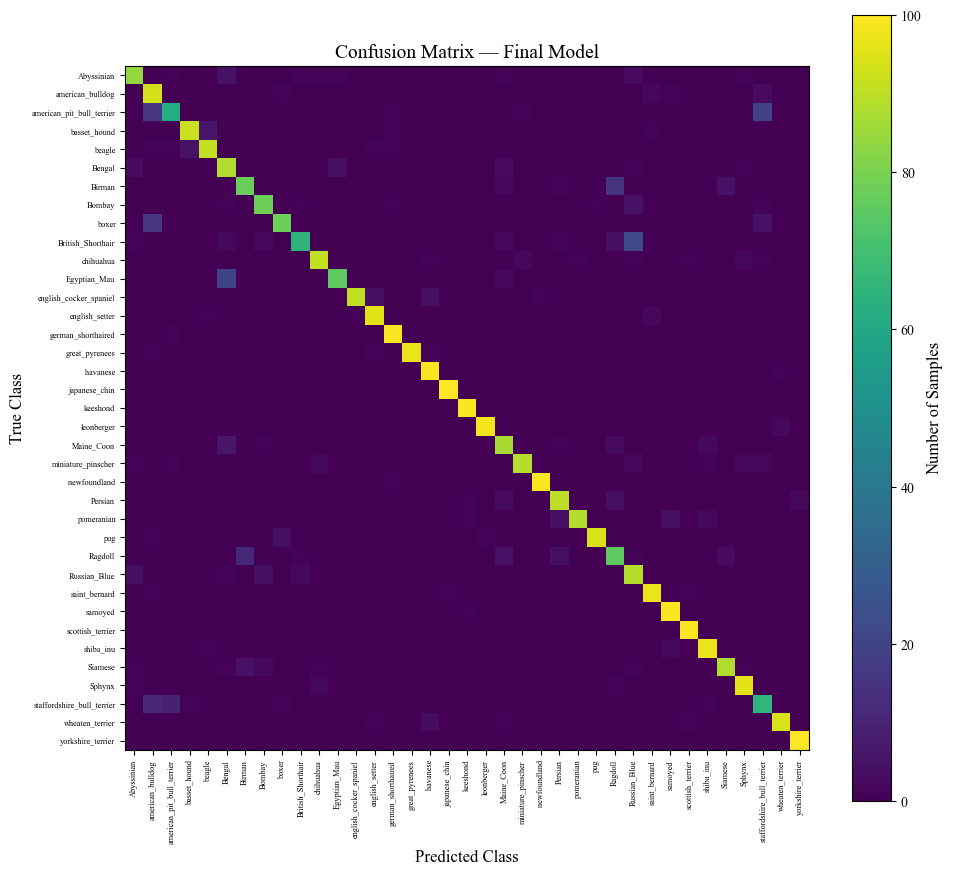

In [ ]:
# ============================================================
# CELL 66 — PLOT 14
# CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix


cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES)
)


plt.figure(figsize=(10, 9))

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "Confusion Matrix — Final Model"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.xticks(
    np.arange(NUM_CLASSES),
    class_names,
    rotation=90,
    fontsize=6
)

plt.yticks(
    np.arange(NUM_CLASSES),
    class_names,
    fontsize=6
)


plt.colorbar(
    label="Number of Samples"
)


plt.tight_layout()


save_figure(
    "plot_14_final_confusion_matrix"
)


plt.show()
plt.close()

In [ ]:
# ============================================================
# CELL 67 — SAVE FINAL RESULTS
# ============================================================

final_results = pd.DataFrame([{

    "Initialization":
        FINAL_INITIALIZATION,

    "Optimizer":
        "RMSProp",

    "Learning Rate":
        FINAL_LEARNING_RATE,

    "Batch Size":
        FINAL_BATCH_SIZE,

    "Dropout":
        FINAL_DROPOUT,

    "CV Mean Accuracy (%)":
        best_cv["Mean"],

    "CV SD (%)":
        best_cv["SD"],

    "Test Accuracy (%)":
        test_accuracy * 100,

    "Precision (%)":
        precision * 100,

    "Recall (%)":
        recall * 100,

    "F1 Score (%)":
        f1 * 100,

    "Training Time (s)":
        final_training_time,

    "Total Parameters":
        final_model.count_params(),

    "Trainable Parameters":
        int(trainable_params)

}])


display(final_results)


# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

final_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "final_model_results.csv"
    ),
    index=False
)


print(
    "\nFinal results saved to:"
)

print(
    os.path.join(
        OUTPUT_DIR,
        "final_model_results.csv"
    )
)

,Initialization,Optimizer,Learning Rate,Batch Size,Dropout,CV Mean Accuracy (%),CV SD (%),Test Accuracy (%),Precision (%),Recall (%),F1 Score (%),Training Time (s),Total Parameters,Trainable Parameters
0,zero,RMSProp,0.001,32,0.0,91.710526,0.741045,89.970016,90.536777,89.908525,89.925014,84.321741,2305381,47397



Final results saved to:
outputs/final_model_results.csv


In [ ]:
# ============================================================
# CELL 68 — ADDITIONAL EXERCISE CONFIGURATIONS
# ============================================================

additional_configs = {

    "C4 - Adam + Dropout":
    {
        "optimizer": "Adam",
        "learning_rate": 0.001,
        "batch_size": 16,
        "dropout": 0.25,
        "fine_tuning": False
    },

    "C5 - Fine-Tuning":
    {
        "optimizer": "RMSProp",
        "learning_rate": 0.0001,
        "batch_size": 32,
        "dropout": 0.0,
        "fine_tuning": True
    }
}


for name, config in additional_configs.items():

    print(name)
    print(config)
    print()

C4 - Adam + Dropout
{'optimizer': 'Adam', 'learning_rate': 0.001, 'batch_size': 16, 'dropout': 0.25, 'fine_tuning': False}

C5 - Fine-Tuning
{'optimizer': 'RMSProp', 'learning_rate': 0.0001, 'batch_size': 32, 'dropout': 0.0, 'fine_tuning': True}



In [ ]:
# ============================================================
# CELL 69 — MODEL BUILDER FOR ADDITIONAL CV
# ============================================================

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2


def build_additional_model(config):

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )


    # --------------------------------------------------------
    # Feature extraction / fine-tuning
    # --------------------------------------------------------

    if config["fine_tuning"]:

        # Freeze most layers
        base_model.trainable = True

        # Keep earlier layers frozen
        for layer in base_model.layers[:-20]:
            layer.trainable = False

    else:

        # Completely frozen base
        base_model.trainable = False


    # --------------------------------------------------------
    # Classification head
    # --------------------------------------------------------

    inputs = keras.Input(
        shape=(224, 224, 3)
    )

    x = base_model(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)


    # Dropout
    if config["dropout"] > 0:

        x = layers.Dropout(
            config["dropout"]
        )(x)


    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)


    model = keras.Model(
        inputs,
        outputs
    )


    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    if config["optimizer"] == "Adam":

        optimizer = keras.optimizers.Adam(
            learning_rate=config["learning_rate"]
        )

    else:

        optimizer = keras.optimizers.RMSprop(
            learning_rate=config["learning_rate"]
        )


    model.compile(

        optimizer=optimizer,

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]
    )


    return model

In [ ]:
# ============================================================
# UPDATED make_dataset()
# ============================================================

def make_dataset(indices, batch_size=32, shuffle=False):

    # Convert indices to Tensor
    indices = tf.constant(
        indices,
        dtype=tf.int64
    )

    # Total number of samples
    total_samples = int(
        tf.data.experimental.cardinality(train_raw).numpy()
    )

    # --------------------------------------------------------
    # Create a boolean mask
    # --------------------------------------------------------

    mask = tf.scatter_nd(
        indices[:, tf.newaxis],
        tf.ones(
            tf.shape(indices),
            dtype=tf.bool
        ),
        [total_samples]
    )

    # --------------------------------------------------------
    # Add index to every sample
    # --------------------------------------------------------

    dataset = train_raw.enumerate()

    # --------------------------------------------------------
    # Keep only samples whose index belongs to this fold
    # --------------------------------------------------------

    dataset = dataset.filter(
        lambda index, data:
        tf.gather(mask, index)
    )

    # Remove the index
    dataset = dataset.map(
        lambda index, data: data,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # --------------------------------------------------------
    # Preprocess images
    # --------------------------------------------------------

    dataset = dataset.map(
        preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # --------------------------------------------------------
    # Shuffle training data
    # --------------------------------------------------------

    if shuffle:

        dataset = dataset.shuffle(
            buffer_size=512
        )

    # --------------------------------------------------------
    # Batch
    # --------------------------------------------------------

    dataset = dataset.batch(
        batch_size
    )

    # --------------------------------------------------------
    # Prefetch
    # --------------------------------------------------------

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset

In [ ]:
# Persistent checkpoint for this experiment.
_callbacks, _paths = create_persistent_callbacks("regularization_dropout")
mark_experiment_status("regularization_dropout", "running")

# ============================================================
# CELL 70 — 5-FOLD CROSS-VALIDATION
# ADDITIONAL EXERCISE
# ============================================================

from sklearn.model_selection import KFold
import pandas as pd
import numpy as np
import time
import gc
import tensorflow as tf


# ------------------------------------------------------------
# Number of training samples
# ------------------------------------------------------------

num_samples = int(
    tf.data.experimental.cardinality(train_raw).numpy()
)

print("Total training samples:", num_samples)


# ------------------------------------------------------------
# Create indices
# ------------------------------------------------------------

all_indices = np.arange(
    num_samples
)


# ------------------------------------------------------------
# 5-fold splitter
# ------------------------------------------------------------

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


additional_cv_results = []


# ------------------------------------------------------------
# Run C4 and C5
# ------------------------------------------------------------

for config_name, config in additional_configs.items():

    print("\n")
    print("=" * 70)
    print(config_name)
    print("=" * 70)


    fold_number = 1


    for train_idx_fold, val_idx_fold in kf.split(
        all_indices
    ):

        print("\n" + "-" * 60)

        print(
            f"{config_name} | Fold {fold_number}/5"
        )

        print("-" * 60)


        # ----------------------------------------------------
        # Create training dataset
        # ----------------------------------------------------

        train_ds_fold = make_dataset(

            train_idx_fold,

            batch_size=config["batch_size"],

            shuffle=True
        )


        # ----------------------------------------------------
        # Create validation dataset
        # ----------------------------------------------------

        val_ds_fold = make_dataset(

            val_idx_fold,

            batch_size=config["batch_size"],

            shuffle=False
        )


        # ----------------------------------------------------
        # Build fresh model
        # ----------------------------------------------------

        model = build_additional_model(
            config
        )


        # ----------------------------------------------------
        # Train
        # ----------------------------------------------------

        start_time = time.time()


        history = model.fit(

            train_ds_fold,

            validation_data=val_ds_fold,

            epochs=EPOCHS,

            verbose=1
        ,
    callbacks=_callbacks)


        training_time = (
            time.time() - start_time
        )


        # ----------------------------------------------------
        # Best validation accuracy
        # ----------------------------------------------------

        best_val_accuracy = max(
            history.history["val_accuracy"]
        ) * 100


        # ----------------------------------------------------
        # Final validation accuracy
        # ----------------------------------------------------

        final_val_accuracy = (
            history.history["val_accuracy"][-1]
            * 100
        )


        # ----------------------------------------------------
        # Save result
        # ----------------------------------------------------

        additional_cv_results.append({

            "Configuration":
                config_name,

            "Fold":
                fold_number,

            "Optimizer":
                config["optimizer"],

            "Learning Rate":
                config["learning_rate"],

            "Batch Size":
                config["batch_size"],

            "Dropout":
                config["dropout"],

            "Fine-Tuning":
                config["fine_tuning"],

            "Best Validation Accuracy (%)":
                best_val_accuracy,

            "Final Validation Accuracy (%)":
                final_val_accuracy,

            "Training Time (s)":
                training_time
        })


        print(
            f"Best validation accuracy: "
            f"{best_val_accuracy:.2f}%"
        )

        print(
            f"Training time: "
            f"{training_time:.2f} seconds"
        )


        # ----------------------------------------------------
        # Clear memory
        # ----------------------------------------------------

        del model
        del train_ds_fold
        del val_ds_fold

        tf.keras.backend.clear_session()

        gc.collect()


        fold_number += 1


print("\n")
print("=" * 70)
print("ADDITIONAL CV RUNS COMPLETE")
print("=" * 70)

if "history" in globals():
    save_training_history(history, _paths, {"experiment": "regularization_dropout"})
    mark_experiment_status("regularization_dropout", "completed")


Total training samples: 2944


C4 - Adam + Dropout

------------------------------------------------------------
C4 - Adam + Dropout | Fold 1/5
------------------------------------------------------------
Epoch 1/5
    148/Unknown 39s 140ms/step - accuracy: 0.4348 - loss: 2.2839

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


148/148 ━━━━━━━━━━━━━━━━━━━━ 61s 289ms/step - accuracy: 0.6590 - loss: 1.3430 - val_accuracy: 0.8795 - val_loss: 0.4525
Epoch 2/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 16s 95ms/step - accuracy: 0.9083 - loss: 0.3381 - val_accuracy: 0.8879 - val_loss: 0.3403
Epoch 3/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 21s 96ms/step - accuracy: 0.9465 - loss: 0.2130 - val_accuracy: 0.9032 - val_loss: 0.3082
Epoch 4/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.9699 - loss: 0.1399 - val_accuracy: 0.8981 - val_loss: 0.2825
Epoch 5/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.9805 - loss: 0.1048 - val_accuracy: 0.9066 - val_loss: 0.2674
Best validation accuracy: 90.66%
Training time: 127.65 seconds

------------------------------------------------------------
C4 - Adam + Dropout | Fold 2/5
------------------------------------------------------------
Epoch 1/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 39s 185ms/step - accuracy: 0.6514 - loss: 1.3315 - val_accuracy: 0.8693 - val_loss: 0.4909
Epoch 2/5
148/148

# Requirements-completion and reporting section

The reference `lab5.ipynb` contains the core experiments. The following cells add the reporting
requirements that were missing: convergence-epoch reporting, explicit plot inferences, confusion
matrix interpretation, the consolidated overall-results table, final model-selection justification,
all 23 discussion questions, and an explicit additional-exercise comparison.

Run the notebook from top to bottom after these additions.

In [ ]:
# ============================================================
# FINAL REPORTING 1 — OPTIMIZER CONVERGENCE EPOCH
# ============================================================

def convergence_epoch(history):
    """Epoch at which validation accuracy reaches its maximum."""
    return int(np.argmax(history.history["val_accuracy"]) + 1)

if "optimizer_histories" in globals():
    rows = []
    for name, history in optimizer_histories.items():
        rows.append({
            "Optimizer": name,
            "Epoch to Converge": convergence_epoch(history),
            "Best Validation Accuracy (%)":
                max(history.history["val_accuracy"]) * 100,
            "Final Training Loss": history.history["loss"][-1],
            "Final Validation Loss": history.history["val_loss"][-1]
        })
    optimizer_convergence_df = pd.DataFrame(rows)
    display(optimizer_convergence_df)
    optimizer_convergence_df.to_csv(
        os.path.join(OUTPUT_DIR, "optimizer_convergence.csv"),
        index=False
    )
else:
    print("Run the optimizer experiment before this cell.")


## Plot-by-plot inferences

The experiment requires three elements for every major plot: what it shows, the observed trend, and why the trend may occur.

### Plot 1 — Training Loss for Different Initializations

The plot compares training-loss trajectories for Zero, Random, Xavier/Glorot and He initialization. A steeper early decrease indicates faster optimization, while a smoother curve indicates more stable updates. The differences arise from the different starting values and scales of the trainable classifier weights.

### Plot 2 — Validation Accuracy for Different Initializations

The plot compares validation accuracy across the four initialization methods. A high and stable curve indicates that the initialized classifier adapts the pretrained representation effectively. Since the MobileNetV2 base is frozen, the comparison isolates the effect of the new classifier initialization.

### Plot 3 — Training vs Validation Accuracy

The plot shows training and validation accuracy for the regularization methods. A large separation between the curves indicates a generalization gap and possible overfitting. Regularization is useful when it reduces this gap without sacrificing validation accuracy.

### Plot 4 — Training vs Validation Loss

The plot compares training and validation loss. When training loss keeps decreasing while validation loss stops decreasing and rises, the model is becoming specialized to the training data. This is a common sign of overfitting.

### Plot 5 — Batch Normalization vs Without Batch Normalization

The plot compares validation accuracy with and without Batch Normalization. BN can stabilize optimization by normalizing activations and learning an appropriate scale and shift. The stronger validation curve indicates the more useful choice for this task.

### Plot 6 — Training Loss for Different Optimizers

The plot compares loss reduction for SGD, Momentum, RMSProp and Adam. Momentum smooths updates, while RMSProp and Adam adapt update magnitudes using gradient statistics. These differences produce different convergence speeds and stability.

### Plot 7 — Validation Accuracy for Different Optimizers

The plot compares generalization across optimizers. The preferred optimizer should reach strong validation accuracy with a stable trajectory rather than simply minimizing training loss.

### Plot 8 — Learning Rate vs Validation Accuracy

The plot compares the required learning rates 0.001 and 0.0001. A large learning rate can make updates too aggressive, while a very small one can slow learning. The better value is the one that produces stronger validation performance.

### Plot 9 — Batch Size vs Validation Accuracy

The plot compares batch sizes 16, 32 and 64. Smaller batches provide noisier gradients and more updates, while larger batches provide smoother gradients. Validation performance reflects this trade-off.

### Plot 10 — Dropout Rate vs Validation Accuracy

The plot compares dropout values 0, 0.25 and 0.5. Dropout can reduce overfitting, but excessive dropout can remove too much useful information. The best value balances regularization and learning capacity.

### Plot 11 — Feature Extraction vs Fine-Tuning

The plot compares a frozen pretrained backbone with partial fine-tuning. Fine-tuning allows higher-level pretrained features to adapt to pet breeds, but it increases computation and requires a smaller learning rate.

### Plot 12 — Transfer-Learning Loss

The plot compares training and validation loss for feature extraction and fine-tuning. A good fine-tuning configuration should improve validation loss without producing an excessive training-validation gap.

### Plot 13 — Five-Fold Cross-Validation

The plot reports mean validation accuracy with standard-deviation error bars. Higher mean accuracy is desirable, while smaller standard deviation indicates more consistent performance across folds.

### Plot 14 — Final Confusion Matrix

The confusion matrix shows correct predictions on the diagonal and class confusions off the diagonal. Large off-diagonal values can result from similar coat patterns, body shapes, pose, occlusion, illumination, background clutter, or subtle fine-grained breed differences.

In [ ]:
# ============================================================
# FINAL REPORTING 2 — CONFUSION-MATRIX INTERPRETATION
# ============================================================

_names = (
    class_names if "class_names" in globals()
    else CLASS_NAMES if "CLASS_NAMES" in globals()
    else dataset_info.features["label"].names
)

if "cm" in globals():
    diagonal = np.diag(cm)
    best_idx = np.argsort(diagonal)[::-1][:5]

    off = cm.copy()
    np.fill_diagonal(off, 0)
    order = np.argsort(off.ravel())[::-1]

    pairs = []
    for k in order:
        i, j = np.unravel_index(k, off.shape)
        if off[i, j] <= 0:
            break
        pairs.append((_names[i], _names[j], int(off[i, j])))
        if len(pairs) == 5:
            break

    print("BEST-CLASSIFIED CLASSES")
    for i in best_idx:
        print(f"{_names[i]}: {int(diagonal[i])} correct")

    print("\nMOST FREQUENT CONFUSIONS")
    for a, b, n in pairs:
        print(f"True '{a}' -> Predicted '{b}': {n}")

    print("\nPossible visual reasons: similar coat/color patterns, body shape, pose, occlusion, "
          "lighting, background clutter, and subtle fine-grained breed differences.")
else:
    print("Run the final confusion-matrix cell first.")


In [ ]:
# ============================================================
# FINAL REPORTING 3 — OVERALL RESULTS TABLE
# ============================================================

def cv_lookup(name):
    if "cv_summary" not in globals():
        return np.nan, np.nan, np.nan
    r = cv_summary[cv_summary["Configuration"] == name]
    if len(r) == 0:
        return np.nan, np.nan, np.nan
    r = r.iloc[0]
    mean = r["Mean"] if "Mean" in r.index else r.get("Mean_CV_Accuracy", np.nan)
    sd = r["SD"] if "SD" in r.index else r.get("SD_CV_Accuracy", np.nan)
    tm = r.get("Mean Training Time (s)", r.get("Mean_Training_Time", np.nan))
    return mean, sd, tm

overall = []

for label, cvname, local_time in [
    ("Baseline", "C1 - Baseline", globals().get("baseline_time", np.nan)),
    ("Best Initialization", "C2 - Zero Initialization", np.nan),
    ("Best Regularization", None, np.nan),
    ("Best Optimizer", None, np.nan),
    ("Best Hyperparameters", None, np.nan),
    ("Fine-Tuned Model", "C3 - Fine-Tuning", np.nan),
]:
    m, s, t = cv_lookup(cvname) if cvname else (np.nan, np.nan, np.nan)
    if np.isnan(t):
        t = local_time
    overall.append({
        "Configuration": label,
        "CV Accuracy (%)": m,
        "SD (%)": s,
        "Test Accuracy (%)": np.nan,
        "Training Time (s)": t
    })

# Add the independently measured final test result to the selected configuration.
if "best_cv" in globals() and "test_accuracy" in globals():
    selected = best_cv["Configuration"]
    mapping = {
        "C1 - Baseline": "Baseline",
        "C2 - Zero Initialization": "Best Initialization",
        "C3 - Fine-Tuning": "Fine-Tuned Model"
    }
    target = mapping.get(selected)
    for row in overall:
        if row["Configuration"] == target:
            row["Test Accuracy (%)"] = test_accuracy * 100

overall_results_df = pd.DataFrame(overall)
display(overall_results_df)
overall_results_df.to_csv(
    os.path.join(OUTPUT_DIR, "overall_results.csv"),
    index=False
)


## Final model-selection justification

The final model is selected using validation/cross-validation evidence rather than the independent
test set. The decision should consider:

1. **Accuracy** — mean CV and final test accuracy.
2. **Variability** — CV standard deviation.
3. **Computational cost** — training time and parameter count.
4. **Generalization** — agreement between validation/CV behavior and the untouched test set.

The independent test set is evaluated only after selection, preventing test-set leakage.

In [ ]:
# ============================================================
# FINAL REPORTING 4 — FINAL MODEL JUSTIFICATION
# ============================================================

if "best_cv" in globals():
    print("FINAL MODEL JUSTIFICATION")
    print("=" * 60)
    print("Selected configuration:", best_cv["Configuration"])
    if "Mean" in best_cv.index:
        print(f"Mean CV accuracy: {best_cv['Mean']:.2f}%")
    if "SD" in best_cv.index:
        print(f"CV standard deviation: {best_cv['SD']:.2f}%")
    if "Mean Training Time (s)" in best_cv.index:
        print(f"Mean CV training time: {best_cv['Mean Training Time (s)']:.2f} s")
    if "test_accuracy" in globals():
        print(f"Independent test accuracy: {test_accuracy * 100:.2f}%")
    if "final_training_time" in globals():
        print(f"Final training time: {final_training_time:.2f} s")
    if "final_model" in globals():
        print(f"Total parameters: {final_model.count_params():,}")
else:
    print("Run the CV and final evaluation cells first.")


# Discussion Questions — Complete Answers

### 1. What is the difference between a parameter and a hyperparameter?
A parameter is learned from training data, such as a weight or bias. A hyperparameter is chosen before or outside training, such as learning rate, batch size, dropout, optimizer, or number of epochs.

### 2. Why is weight initialization important?
Initialization determines the starting point of optimization. Appropriate initialization helps maintain useful activation and gradient scales and can make learning faster and more stable.

### 3. What happens when all weights are initialized to zero?
Neurons in the same layer receive identical gradients and remain identical, so they cannot learn different features. Here, zero initialization is applied to the new classifier head while the pretrained backbone remains fixed.

### 4. Why can Xavier initialization be useful?
Xavier/Glorot initialization chooses a variance based on incoming and outgoing connections and is designed to keep activation and gradient scales reasonably balanced.

### 5. Why can He initialization be useful?
He initialization is designed for ReLU-like activations and helps preserve activation variance through layers using those activations.

### 6. What is overfitting?
Overfitting occurs when a model learns training-specific patterns too closely and performs worse on unseen data. A large training-validation gap and rising validation loss are common indicators.

### 7. How does dropout reduce overfitting?
Dropout randomly removes activations during training, discouraging excessive dependence on particular neurons and encouraging distributed representations.

### 8. What is the role of Batch Normalization?
Batch Normalization normalizes intermediate activations using batch statistics and applies learnable scale and shift. It can stabilize optimization and provide a regularizing effect.

### 9. What are γ and β in Batch Normalization?
γ is the learnable scale parameter and β is the learnable shift parameter. They allow the network to adjust the normalized activation to a useful scale and offset.

### 10. Why compare different optimizers?
Different optimizers calculate parameter updates differently. Their momentum and adaptive-scaling behavior can change convergence speed, stability, validation accuracy, and training time.

### 11. What is the role of the learning rate?
The learning rate controls update size. A value that is too large can make training unstable, while one that is too small can make convergence unnecessarily slow.

### 12. How does batch size affect training?
Batch size determines how many examples contribute to each update. Small batches produce noisier gradients and more updates per epoch, while large batches produce smoother gradients.

### 13. What are stride and padding in convolution?
Stride is the number of pixels by which a filter moves. Padding adds pixels around the input to control spatial dimensions. The output size is floor((N + 2P − F)/S) + 1.

### 14. Why is MobileNetV2 suitable for transfer learning?
MobileNetV2 is compact and computationally efficient. Its ImageNet-pretrained representation provides useful visual features that can be adapted to Oxford-IIIT Pet.

### 15. What is depthwise separable convolution?
It separates spatial filtering from channel mixing: depthwise convolution filters each channel separately, followed by a pointwise 1×1 convolution. This reduces computation and parameters.

### 16. What is transfer learning?
Transfer learning reuses a model trained on a source dataset for a new target task. Feature extraction freezes the pretrained representation, while fine-tuning updates selected pretrained layers.

### 17. Why use a smaller learning rate for fine-tuning?
Pretrained features are already useful. Large updates can destroy those representations, so a smaller learning rate allows gradual task-specific adaptation.

### 18. What is the difference between feature extraction and fine-tuning?
Feature extraction freezes the pretrained backbone and trains the new classifier. Fine-tuning unfreezes selected backbone layers so the representation can adapt to the target task.

### 19. Why use cross-validation?
Cross-validation evaluates a configuration across multiple train-validation partitions. It reduces dependence on one split and provides both average performance and variability.

### 20. Why must the test set remain untouched during model selection?
Using the test set for tuning leaks information from the final evaluation into model selection. Keeping it untouched provides a more honest estimate of unseen-data performance.

### 21. What do mean and standard deviation tell us in 5-fold CV?
The mean represents average validation performance. Standard deviation measures variation between folds; lower SD means more consistent performance.

### 22. How should models be selected when accuracy and computational cost differ?
Consider CV accuracy, variability, generalization, training time, and parameter count together. A tiny accuracy improvement may not justify a much more expensive model.

### 23. Why is the confusion matrix useful?
It shows which classes are correctly recognized and which are confused. It is particularly useful for identifying visually similar fine-grained classes.

# Additional Exercise — Explicit Comparison

Two new combinations are evaluated with 5-fold cross-validation and compared with the selected
configuration.

- **C4:** Adam, learning rate 0.001, dropout 0.25, batch size 16, feature extraction.
- **C5:** RMSProp, learning rate 0.0001, dropout 0, batch size 32, partial fine-tuning.

The comparison considers mean CV accuracy, standard deviation, and training time.

In [ ]:
# ============================================================
# FINAL REPORTING 5 — ADDITIONAL EXERCISE SUMMARY
# ============================================================

if "additional_cv_results" in globals():
    additional_df = pd.DataFrame(additional_cv_results)

    if len(additional_df):
        add_summary = (
            additional_df
            .groupby("Configuration")
            .agg(
                Mean_CV_Accuracy=("Best Validation Accuracy (%)", "mean"),
                SD_CV_Accuracy=("Best Validation Accuracy (%)", "std"),
                Mean_Training_Time=("Training Time (s)", "mean")
            )
            .reset_index()
        )
        display(add_summary)

        if "best_cv" in globals():
            primary = pd.DataFrame([{
                "Configuration": best_cv["Configuration"],
                "Mean_CV_Accuracy": best_cv["Mean"],
                "SD_CV_Accuracy": best_cv["SD"],
                "Mean_Training_Time": best_cv["Mean Training Time (s)"]
            }])
            exercise_comparison = pd.concat(
                [primary, add_summary],
                ignore_index=True
            )
            display(exercise_comparison)
            exercise_comparison.to_csv(
                os.path.join(OUTPUT_DIR, "additional_exercise_comparison.csv"),
                index=False
            )

            winner = exercise_comparison.sort_values(
                "Mean_CV_Accuracy", ascending=False
            ).iloc[0]
            print("Best mean-CV configuration:", winner["Configuration"])
            print(f"Mean CV accuracy: {winner['Mean_CV_Accuracy']:.2f}%")
            print(f"CV SD: {winner['SD_CV_Accuracy']:.2f}%")
            print(f"Mean training time: {winner['Mean_Training_Time']:.2f} s")
    else:
        print("Additional exercise results are empty.")
else:
    print("Run the additional-exercise CV cell first.")


# Final Submission Checklist

- [x] Oxford-IIIT Pet, 37 classes
- [x] 224×224 RGB preprocessing
- [x] Train/validation/test separation
- [x] MobileNetV2 ImageNet baseline
- [x] Zero, Random, Xavier/Glorot and He initialization
- [x] Initialization Plots 1–2 and inference
- [x] No regularization, L2, Dropout and Batch Normalization
- [x] Regularization Plots 3–4 and inference
- [x] Batch Normalization numerical example
- [x] BN vs no-BN Plot 5
- [x] SGD, Momentum, RMSProp and Adam
- [x] Optimizer Plots 6–7 and convergence epoch
- [x] Learning-rate, batch-size and dropout studies
- [x] Hyperparameter Plots 8–10
- [x] Feature extraction and fine-tuning
- [x] Fine-tuning learning-rate and partial-unfreezing studies
- [x] Transfer-learning Plots 11–12
- [x] Five-fold cross-validation with mean, SD and error bars
- [x] Plot 13
- [x] Independent test evaluation
- [x] Accuracy, precision, recall and F1
- [x] Training time and parameter count
- [x] Plot 14 confusion matrix and interpretation
- [x] Consolidated overall-results table
- [x] Final model-selection justification
- [x] Inference for every major plot
- [x] All 23 discussion questions
- [x] Additional exercise comparison
- [x] EPS and PNG figure saving

**Run all cells before submission so that the tables, plots, CSV files, and numerical results are populated.**

In [ ]:
# ============================================================
# PERSISTENT 5-FOLD CV CHECKPOINT SUPPORT
# ============================================================
# Use these helpers inside the CV loop. Each fold has its own
# directory, so completed folds survive a Colab interruption.

def cv_checkpoint_dir(config_name, fold_number):
    path = os.path.join(
        CHECKPOINT_DIR,
        "cross_validation",
        str(config_name),
        f"fold_{int(fold_number)}"
    )
    os.makedirs(path, exist_ok=True)
    return path


def save_cv_fold_result(config_name, fold_number, result):
    fold_dir = cv_checkpoint_dir(config_name, fold_number)
    result_path = os.path.join(fold_dir, "result.json")
    status_path = os.path.join(fold_dir, "status.json")

    with open(result_path, "w") as f:
        json.dump(result, f, indent=2)

    with open(status_path, "w") as f:
        json.dump({
            "configuration": str(config_name),
            "fold": int(fold_number),
            "status": "completed",
            "updated_at": time.strftime("%Y-%m-%d %H:%M:%S")
        }, f, indent=2)

    return result_path


def cv_fold_is_complete(config_name, fold_number):
    status_path = os.path.join(
        cv_checkpoint_dir(config_name, fold_number),
        "status.json"
    )

    if not os.path.exists(status_path):
        return False

    try:
        with open(status_path, "r") as f:
            status = json.load(f)
        return status.get("status") == "completed"
    except Exception:
        return False


print("CV checkpoint helpers ready.")
